# **Introducción al análisis de datos en Python** 
#### Profesor: Lucas Gómez Tobón

## Clase 7. Visualizaciones, Regresión lineal, Introducción al Webscraping

### Manipulación de fechas

In [1]:
import os 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
os.chdir("../Datos")

## Ejercicios
Vamos a utilizar un conjunto de bases de datos de la tienda brasileña de comercio electrónico Olist. Los datos tienen información de alrededor de 100 mil pedidos entre 2016 y 2018 y dependiendo de la base podrá ver diferentes dimensiones de cada pedido como el estado, el precio, el pago, el rendimiento del flete, la ubicación del cliente, los atributos del producto, las reseñas escritas por los clientes, etc. Notará además que algunos datos tienen una geolocalización que relaciona los códigos postales brasileños con las coordenadas latitud/longitud.

Los datos que manipulará a continuación son datos comerciales reales, sin embargo se han anonimizado y las referencias a las empresas y socios en el texto de revisión se han reemplazado con los nombres de las grandes casas de Game of Thrones.

El esquema de los datos se presenta en la siguiente figura: 
<center>
<div>
<img src="img/diagrama_bases.png" width="800"/>
</div>
</center>

Para más información puede visitar la siguiente [competencia de Kaggle](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce)

Luego de entender el esquema de datos, el primer paso es importar e inspeccionar someramente las siguientes bases de datos:
1. Importe la base de datos `olist_customers_dataset.csv` para obtener los directorios de clientes.
2. Importe la base de datos `olist_geolocation_dataset.csv` para obtener la información espacial de [Brasil](https://es.wikipedia.org/wiki/Geograf%C3%ADa_de_Brasil#/media/Archivo:Brasil_administrative_map_ES.png).
3. Importe la base de datos `olist_order_payments_dataset.csv` para obtener información sobre los pagos.
4. Importe la base de datos `olist_order_items_dataset.csv` para obtener la información de los productos vendidos.
5. Importe la base de datos `olist_products_dataset.csv` para obtener información de los productos.
6. Importe la base de datos `olist_sellers_dataset.csv` para obtener la información de los vendedores.
7. Importe la base de datos `olist_orders_dataset.csv` para obtener información de las entregas.
8. Importe la base de datos `product_category_name_translation.csv` para traducir a inglés los tipos de productos

In [3]:
clientes = pd.read_csv('olist_customers_dataset.csv')
clientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [4]:
clientes.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
geo_brasil = pd.read_csv('olist_geolocation_dataset.csv')
geo_brasil.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [6]:
geo_brasil.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [7]:
pagos = pd.read_csv('olist_order_payments_dataset.csv' )
pagos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [8]:
pagos.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [9]:
ventas = pd.read_csv('olist_order_items_dataset.csv' )
ventas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [10]:
ventas.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [11]:
productos = pd.read_csv('olist_products_dataset.csv' )
productos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [12]:
productos.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [13]:
vendedores = pd.read_csv('olist_sellers_dataset.csv' )
vendedores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


In [14]:
vendedores.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


In [15]:
entregas = pd.read_csv('olist_orders_dataset.csv' )
entregas.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [16]:
entregas.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [17]:
traduccion = pd.read_csv('product_category_name_translation.csv')
traduccion.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [18]:
traduccion.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


### Estadísticas Descriptivas Nivel I
1. ¿Qué bases se pueden pegar directamente? No debe realizar el pegue, solo debe escribir su respuesta.

A partir del esquema de los datos se pueden identificar que las llaves para pegar los datos son: `order_id`, `customer_id`, `product_id`, `zip_code_prefix` y `seller_id`. En ese orden de ideas, los pegues que se pueden hacer según la llave serían:

1. Las bases que se pueden relacionar directamente a partir de `order_id` son:
- `olist_order_reviews_dataset`
- `olist_orders_dataset`
- `olist_orders_payment_dataset`
- `olist_order_items_dataset`
2. Las bases que se pueden relacionar directamente a partir de `customer_id` son:
- `olist_orders_dataset`
- `olist_order_customer_dataset`
3. Las bases que se pueden relacionar directamente a partir de `product_id` son:
- `olist_products_dataset`
- `olist_order_items_dataset`
4. Las bases que se pueden relacionar directamente a partir de `zip_code_prefix` son:
- `olist_order_customer_dataset`
- `olist_geolocation_dataset`
- `olist_sellers_dataset`
5. Las bases que se pueden relacionar directamente a partir de `seller_id` son:
- `olist_order_items_dataset`
- `olist_sellers_dataset`

2. ¿Cuál fue el producto más vendido? ¿Qué tipo de producto es (en inglés)?

In [19]:
# El producto más vendido
mas_vendido = ventas["product_id"].value_counts().index[0]
mas_vendido

'aca2eb7d00ea1a7b8ebd4e68314663af'

In [20]:
# ¿Cuál es la categoría de dicho producto?
categoria = productos.loc[productos.product_id == mas_vendido, "product_category_name"].values[0]
categoria

'moveis_decoracao'

In [21]:
# ¿Cuál es el nombre del producto en inglés?
traduccion.loc[traduccion.product_category_name == categoria, "product_category_name_english"].values[0]

'furniture_decor'

3. Pegue a la tabla de productos con la de traducción.

In [22]:
productos2 = productos.merge(traduccion, how = "left", on = "product_category_name")
productos.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [23]:
productos2.isna().sum()

product_id                         0
product_category_name            610
product_name_lenght              610
product_description_lenght       610
product_photos_qty               610
product_weight_g                   2
product_length_cm                  2
product_height_cm                  2
product_width_cm                   2
product_category_name_english    623
dtype: int64

4. ¿Cuánto se gastó en promedio por compra?

In [24]:
# En promedio se gastó 120 reales
ventas["price"].mean()

120.65373901477311

5. ¿Cómo se distribuyo el tipo de pago? 

In [25]:
tipo_pago = pagos["payment_type"].value_counts().reset_index()
tipo_pago 

,index,payment_type
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


<AxesSubplot:xlabel='Tipo de pago', ylabel='Cantidad'>

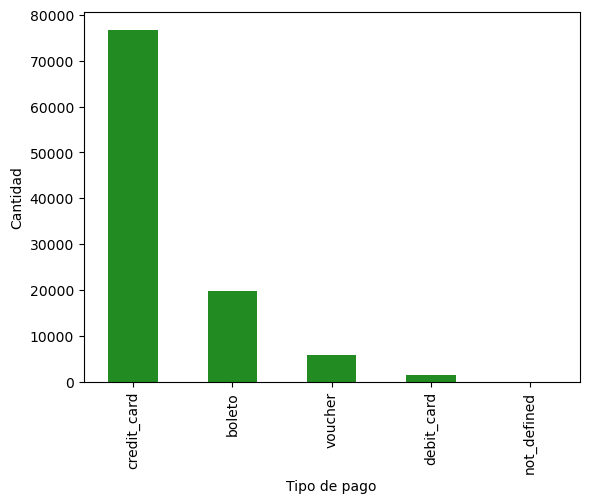

In [26]:
tipo_pago.plot(x = "index", y = "payment_type", kind = "bar", 
               xlabel = "Tipo de pago", ylabel = "Cantidad", 
               legend = False, color = "forestgreen")

In [27]:
tipo_pago

,index,payment_type
0,credit_card,76795
1,boleto,19784
2,voucher,5775
3,debit_card,1529
4,not_defined,3


<AxesSubplot:>

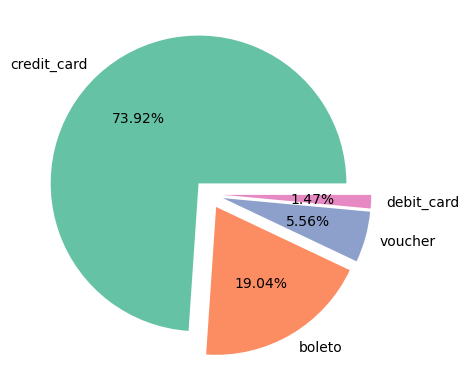

In [28]:
tipo_pago[0:4].plot(labels = tipo_pago["index"].values[0:4], y = "payment_type", kind = "pie", 
                    legend = False, autopct = "%1.2f%%", 
                    ylabel = "", 
                    colors = sns.color_palette("Set2"),
                    explode = [0.1, 0.1, 0.1, 0.1])

6. ¿Cuánto se gastó en promedio por tipo de producto? 

In [29]:
ventas2 = ventas.merge(productos2, how = "left", on = 'product_id')
precio_promedio = ventas2.groupby('product_category_name_english')['price'].mean().reset_index() \
    .sort_values("price", ascending = False)

<AxesSubplot:xlabel='product_category_name_english'>

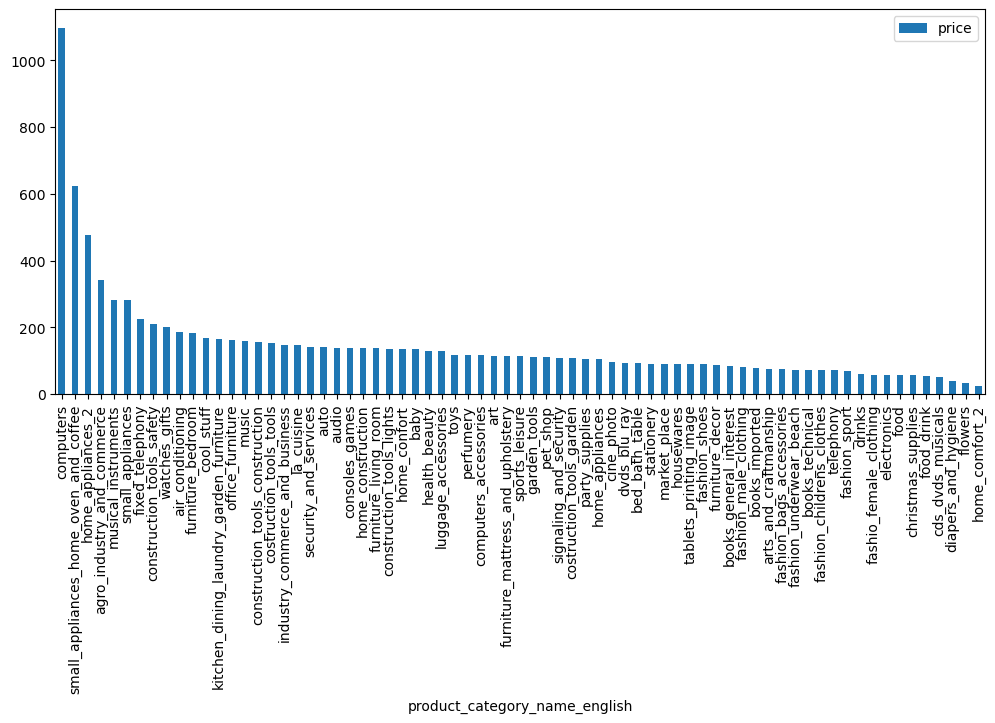

In [30]:
precio_promedio.plot(x = "product_category_name_english", y = "price", kind = "bar",
                     figsize = (12, 5))

¿Cómo funciona `plt.subplots()`?

En la línea de código `fig, ax = plt.subplots()`, `fig` y `ax` son dos variables que se utilizan para almacenar los objetos de figura y ejes devueltos por la función `plt.subplots()`, respectivamente.

La variable `fig` almacena el objeto de figura que representa toda la ventana o lienzo de la gráfica, mientras que la variable `ax` almacena el objeto de ejes que representa una región rectangular dentro de la figura donde los gráficos se trazan.

Es importante tener en cuenta que la función `plt.subplots()` devuelve dos valores, una figura y un arreglo de ejes. El arreglo de ejes es una matriz de objetos de ejes, y su tamaño está determinado por el número de filas y columnas especificados como argumentos en la función `plt.subplots()`. Si no se especifican estos argumentos, se utiliza un valor predeterminado de una sola fila y una sola columna.

Una vez que se han almacenado los objetos de figura y ejes en las variables `fig` y `ax`, respectivamente, podemos usarlos para personalizar la figura y agregar diferentes tipos de gráficos en el conjunto de ejes. Por ejemplo, podemos cambiar el tamaño de la figura, agregar títulos y etiquetas de eje, cambiar los colores y estilos de las líneas, y mucho más.

In [31]:
import matplotlib.pyplot as plt
import numpy as np

In [32]:
# Generar algunos datos de ejemplo
x = np.linspace(0, 2*np.pi, 100)
x

array([0.        , 0.06346652, 0.12693304, 0.19039955, 0.25386607,
       0.31733259, 0.38079911, 0.44426563, 0.50773215, 0.57119866,
       0.63466518, 0.6981317 , 0.76159822, 0.82506474, 0.88853126,
       0.95199777, 1.01546429, 1.07893081, 1.14239733, 1.20586385,
       1.26933037, 1.33279688, 1.3962634 , 1.45972992, 1.52319644,
       1.58666296, 1.65012947, 1.71359599, 1.77706251, 1.84052903,
       1.90399555, 1.96746207, 2.03092858, 2.0943951 , 2.15786162,
       2.22132814, 2.28479466, 2.34826118, 2.41172769, 2.47519421,
       2.53866073, 2.60212725, 2.66559377, 2.72906028, 2.7925268 ,
       2.85599332, 2.91945984, 2.98292636, 3.04639288, 3.10985939,
       3.17332591, 3.23679243, 3.30025895, 3.36372547, 3.42719199,
       3.4906585 , 3.55412502, 3.61759154, 3.68105806, 3.74452458,
       3.8079911 , 3.87145761, 3.93492413, 3.99839065, 4.06185717,
       4.12532369, 4.1887902 , 4.25225672, 4.31572324, 4.37918976,
       4.44265628, 4.5061228 , 4.56958931, 4.63305583, 4.69652

In [33]:
y1 = np.sin(x)
y2 = np.cos(x)

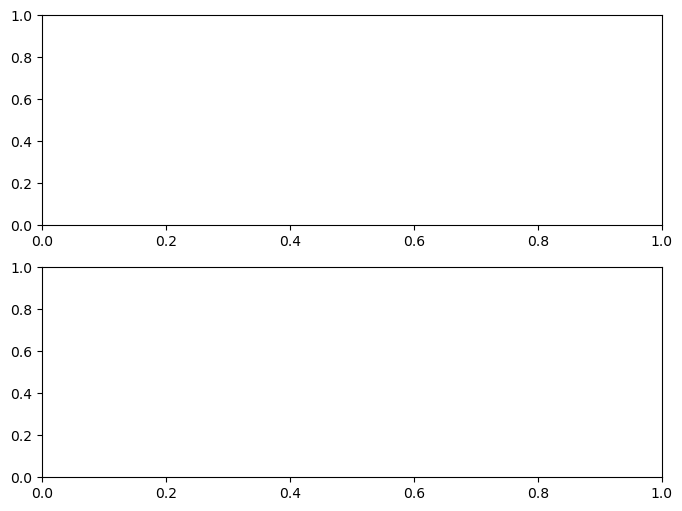

In [34]:
# Crear una figura y dos conjuntos de ejes
fig, ax = plt.subplots(nrows = 2, ncols = 1, figsize = (8, 6))

In [35]:
# Graficar la función seno en el primer conjunto de ejes
ax[0].plot(x, y1, color = 'blue', label = 'Seno')
ax[0].set_title('Conjunto de ejes 1')
ax[0].legend()

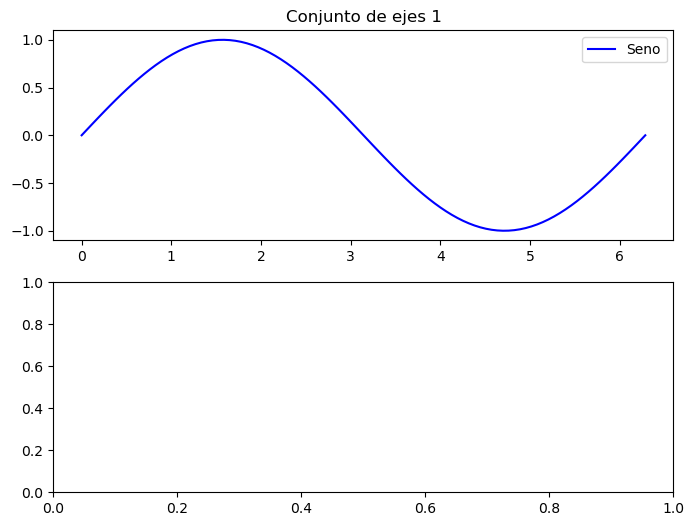

In [36]:
fig

In [37]:
# Graficar la función coseno en el segundo conjunto de ejes
ax[1].plot(x, y2, color = 'red', label=  'Coseno')
ax[1].set_title('Conjunto de ejes 2')
ax[1].legend()

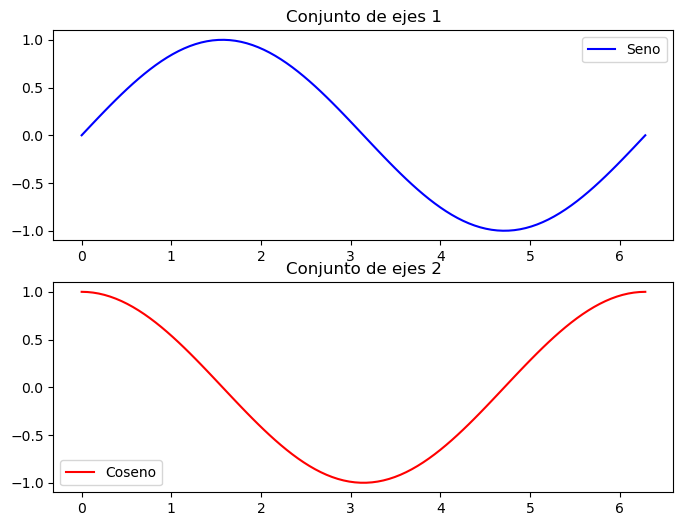

In [38]:
fig

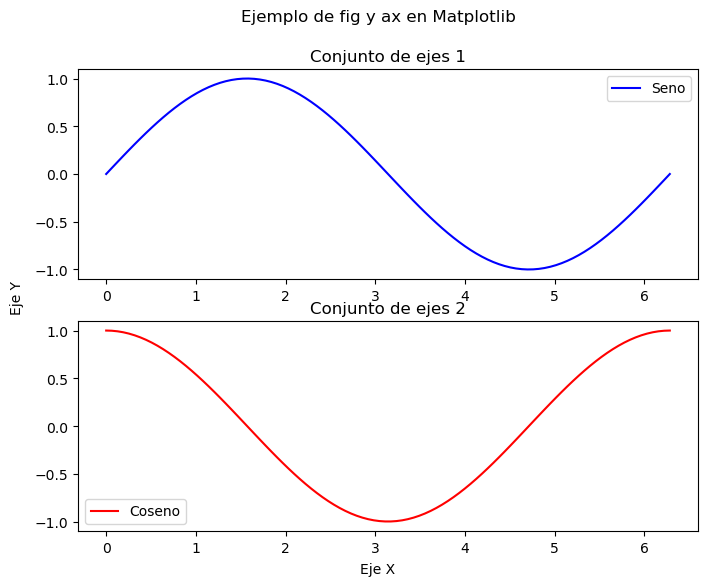

In [39]:
# Agregar título y etiquetas de eje a la figura
fig.suptitle('Ejemplo de fig y ax en Matplotlib')
fig.text(0.5, 0.04, 'Eje X', ha = 'center')
fig.text(0.04, 0.5, 'Eje Y', va = 'center', rotation = 'vertical')

# Mostrar la figura
fig

Text(0.5, 1.0, 'Precio promedio por categoría')

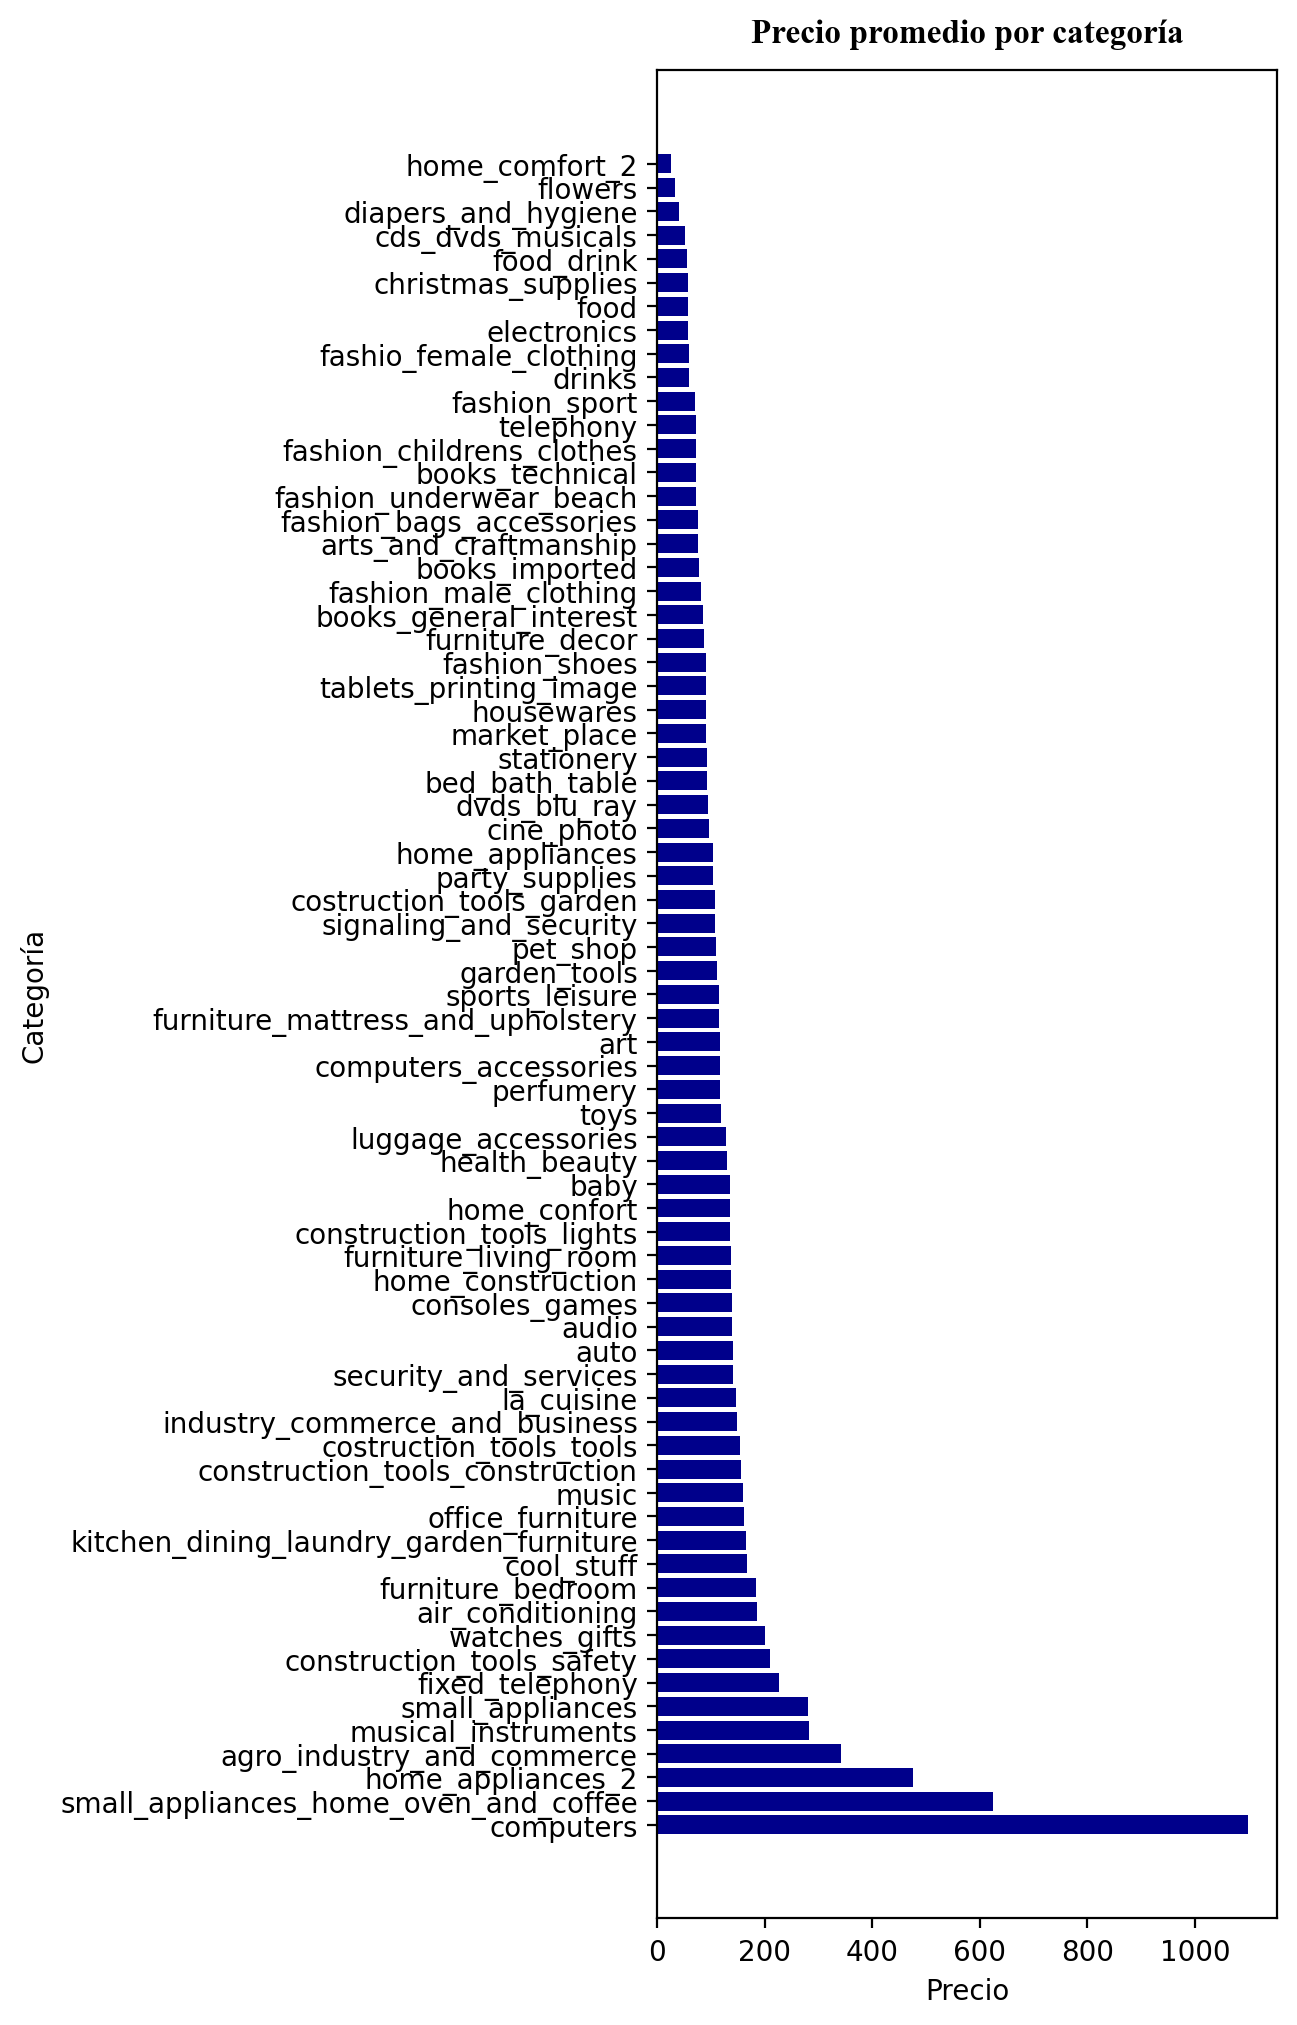

In [40]:
fig, ax = plt.subplots(figsize = (4, 12), dpi = 200)
ax.barh(width = precio_promedio["price"], y = precio_promedio["product_category_name_english"], color = "darkblue")
ax.set_xlabel("Precio") # plt.xlabel("Precio")
ax.set_ylabel("Categoría") # plt.ylabel("Categoría")
ax.set_title("Precio promedio por categoría", fontsize = 12, pad = 10, 
             fontname = "Times New Roman", fontweight = "bold") # plt.title()

7. ¿Cómo se distribuye el volumen de ventas por tipo de producto?

In [41]:
# Cantidad de ventas por productos
cantidades_productos = ventas2.groupby('product_category_name_english').size().reset_index(name = "Cantidad")
cantidades_productos = cantidades_productos.sort_values("Cantidad", ascending = False)

Text(0.5, 1.0, 'Número de productos vendidos por categoría')

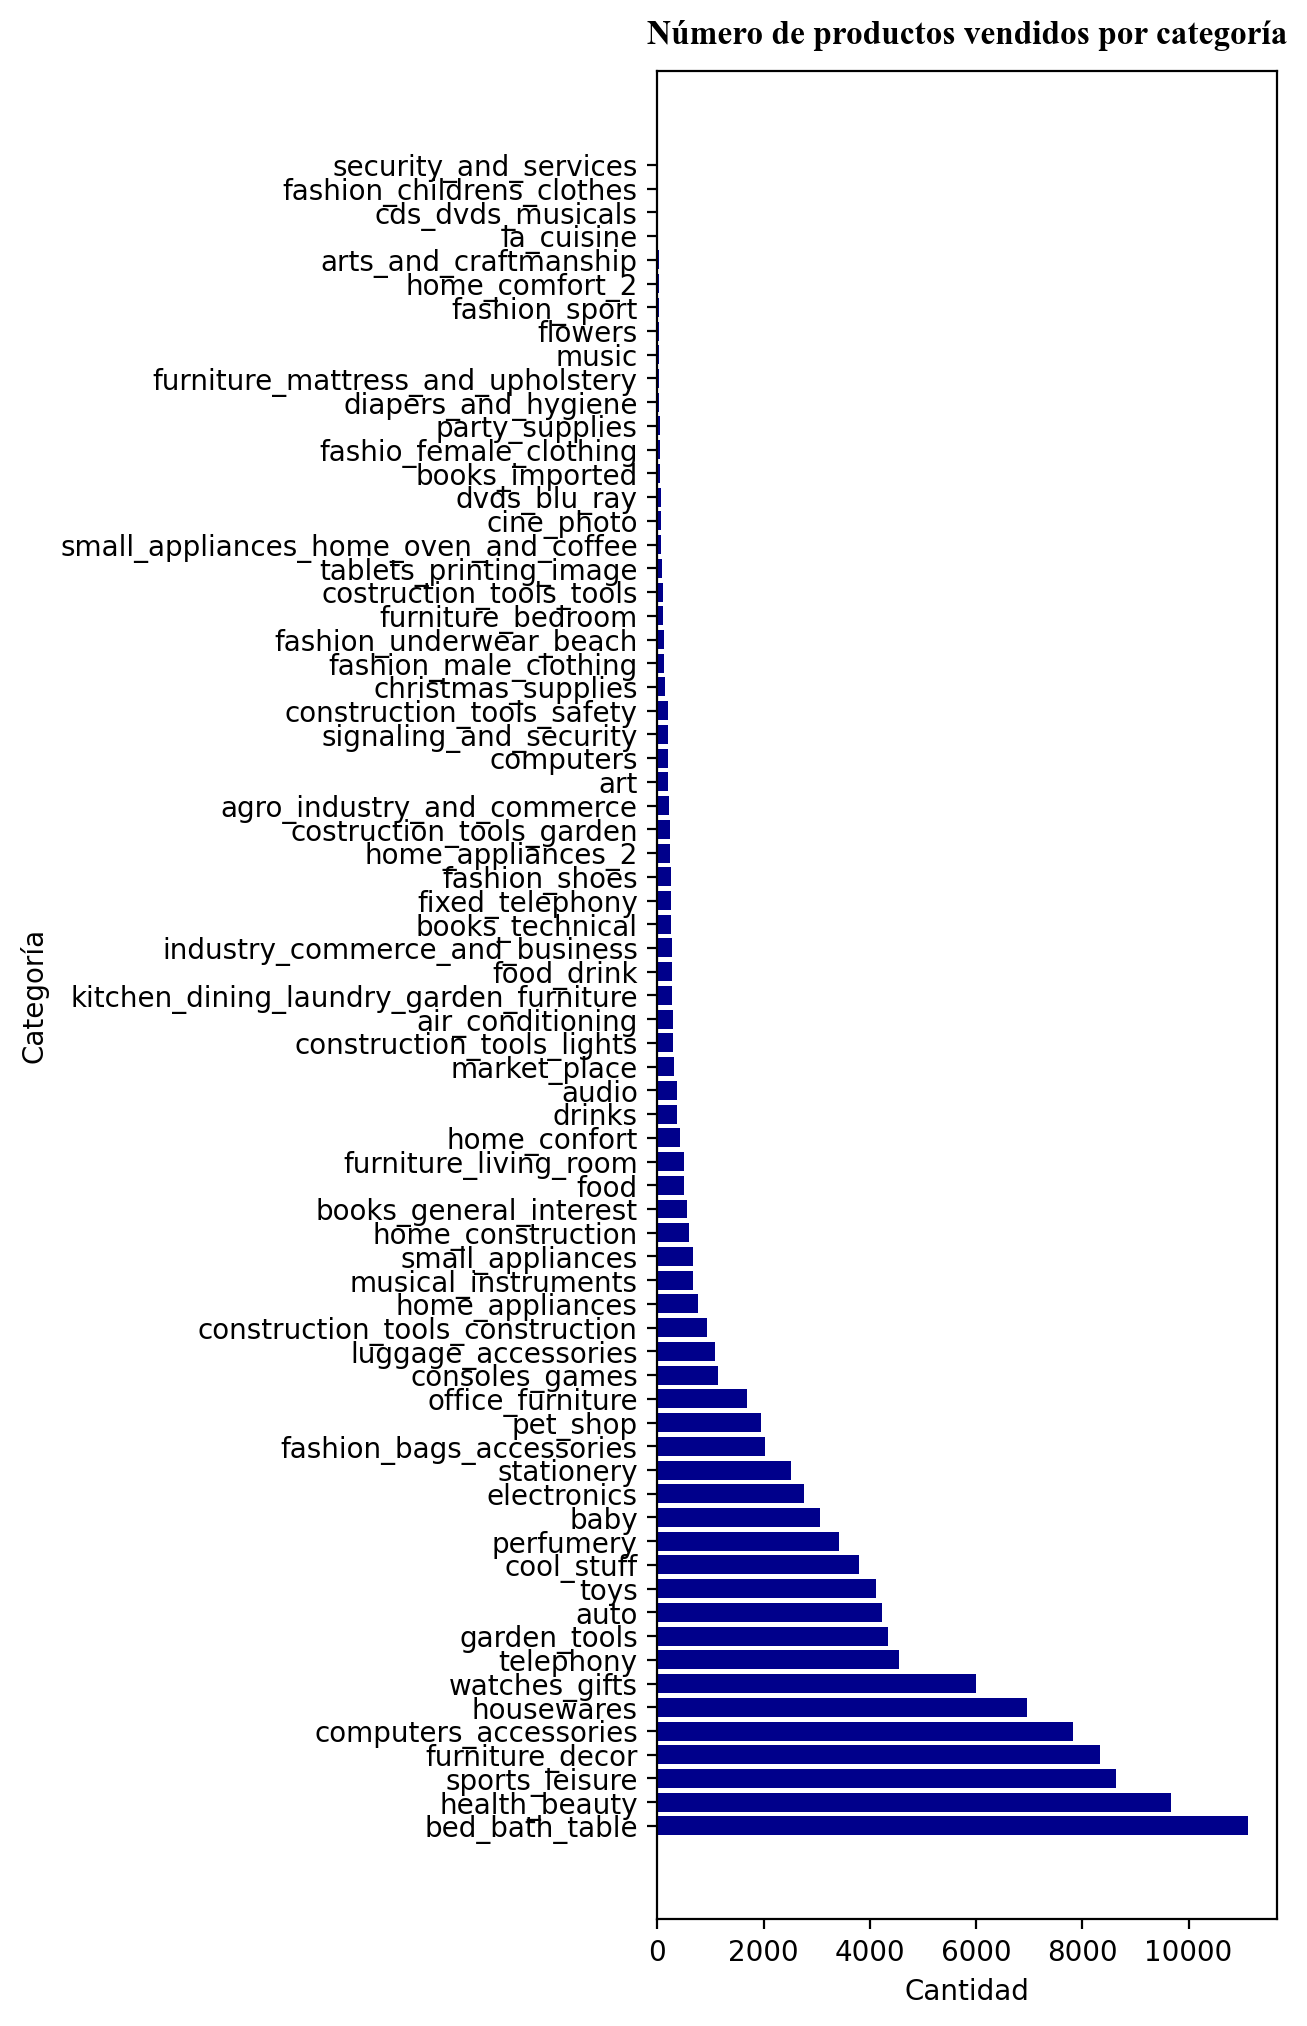

In [42]:
fig, ax = plt.subplots(figsize = (4, 12), dpi = 200)
ax.barh(width = cantidades_productos["Cantidad"], y = cantidades_productos["product_category_name_english"], 
        color = "darkblue")
plt.xlabel("Cantidad")
plt.ylabel("Categoría")
plt.title("Número de productos vendidos por categoría", fontsize = 12, pad = 10, 
          fontname = "Times New Roman", fontweight = "bold")

8. Construya la serie de tiempo de las ventas diarias

In [43]:
ventas3 = ventas2.merge(entregas, on = 'order_id', how = "left")

In [44]:
# Creamos la variable fecha de compra
ventas3["order_purchase_timestamp"] = pd.to_datetime(ventas3["order_purchase_timestamp"]) 
ventas3["order_purchase_timestamp"].head()

0   2017-09-13 08:59:02
1   2017-04-26 10:53:06
2   2018-01-14 14:33:31
3   2018-08-08 10:00:35
4   2017-02-04 13:57:51
Name: order_purchase_timestamp, dtype: datetime64[ns]

In [45]:
ventas3["fechas_compra"] = ventas3["order_purchase_timestamp"].dt.date
ventas3["fechas_compra"].head()

0    2017-09-13
1    2017-04-26
2    2018-01-14
3    2018-08-08
4    2017-02-04
Name: fechas_compra, dtype: object

In [46]:
# Número de ventas por día
serie_compras = ventas3.groupby('fechas_compra').size().reset_index(name = "n")
serie_compras.head()

,fechas_compra,n
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-15,3
3,2016-10-02,1
4,2016-10-03,8


<AxesSubplot:xlabel='fechas_compra'>

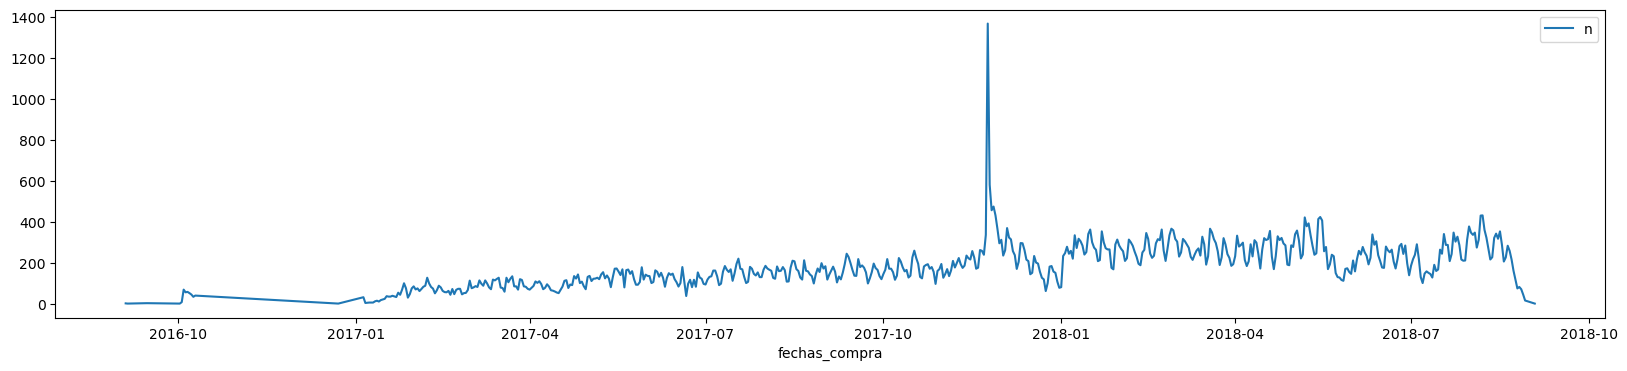

In [47]:
serie_compras.plot(x = "fechas_compra", y = "n", figsize = (20, 4))

Ahora vamos a analizar como se correlaciona la serie con sus rezagos:

In [48]:
serie_compras.head()

,fechas_compra,n
0,2016-09-04,2
1,2016-09-05,1
2,2016-09-15,3
3,2016-10-02,1
4,2016-10-03,8


In [49]:
# Rezago (lag) de 1
serie_compras["n"].shift(1)

0       NaN
1       2.0
2       1.0
3       3.0
4       1.0
       ... 
611    75.0
612    82.0
613    71.0
614    45.0
615    16.0
Name: n, Length: 616, dtype: float64

In [50]:
# Rezago (lag) de 2
serie_compras["n"].shift(2)

0        NaN
1        NaN
2        2.0
3        1.0
4        3.0
       ...  
611    117.0
612     75.0
613     82.0
614     71.0
615     45.0
Name: n, Length: 616, dtype: float64

In [51]:
# Hacia adelante (lead) de 1
serie_compras["n"].shift(-1)

0       1.0
1       3.0
2       1.0
3       8.0
4      69.0
       ... 
611    71.0
612    45.0
613    16.0
614     1.0
615     NaN
Name: n, Length: 616, dtype: float64

In [52]:
# Hacia adelante (lead) de 2
serie_compras["n"].shift(-2)

0       3.0
1       1.0
2       8.0
3      69.0
4      56.0
       ... 
611    45.0
612    16.0
613     1.0
614     NaN
615     NaN
Name: n, Length: 616, dtype: float64

Vamos a utilizar la función `np.corrcoef()` para calcular la correlación entre la serie y sus rezagos:

$$\rho_{X,Y} = \frac{\sigma_{XY}}{\sigma_X \sigma_Y} = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2}\sqrt{\sum (y_i - \bar{y})^2}}.$$

In [53]:
# Correlación del numero de ventas diarias con su serie rezagada 1, 2, ... 30, días 
correlaciones = []
for i in range(1,31):   
    # Ojo. Cuando creamos los rezagos, tenemos NAs (no sabemos que hay antes de la primera observación)
    # Luego, es necesario no tener en cuenta los períodos faltantes en el cálculo de la correlación 
    X = serie_compras["n"][i:]
    Y = serie_compras["n"].shift(i)[i:]
    corr = np.corrcoef(X, Y)
    corr = corr[1,0]
    correlaciones.append(corr) 

Note que en la medida que aumenta el rezago, se disminuye la correlación, sin embargo, hay un patrón en el que rezagos múltiplos de 7 tienen una correlación superior a la esperada. Esto señala que nuestra serie tiene un efecto semanal, las ventas se pueden explicar en gran medida por el día de la semana.

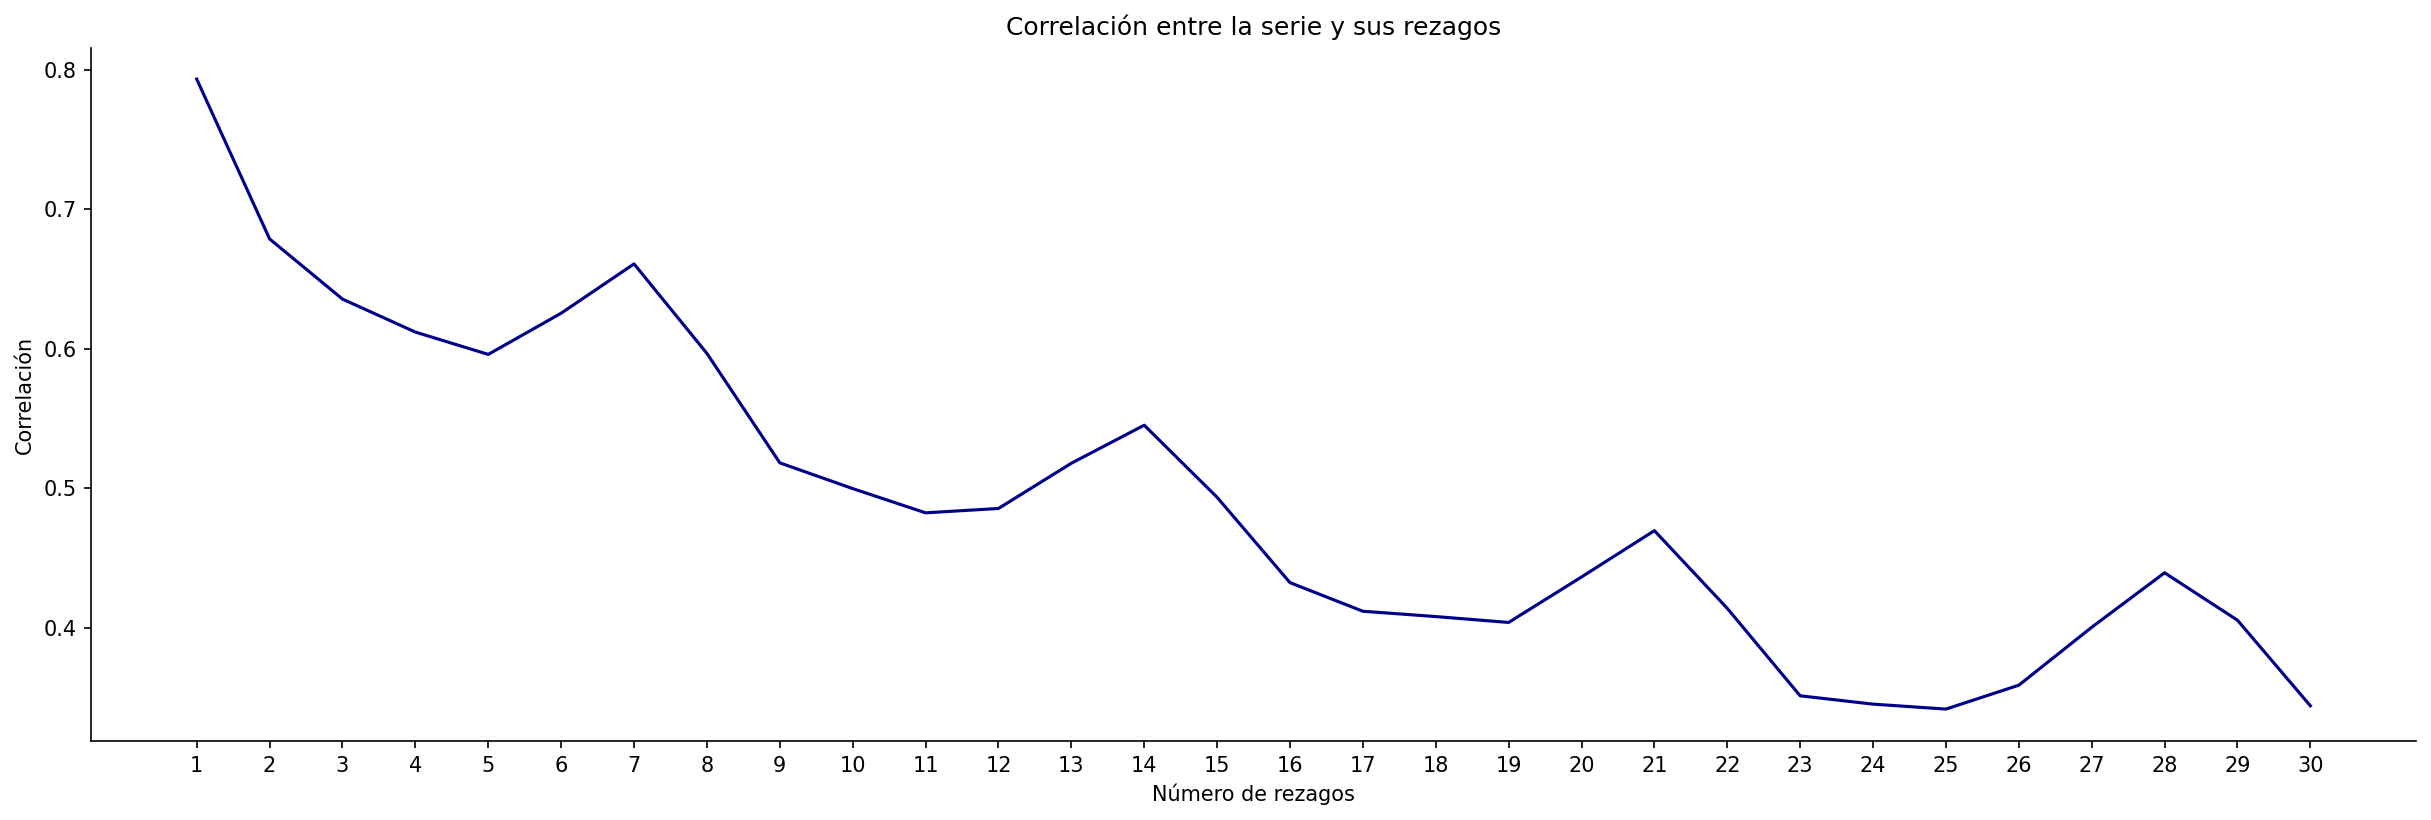

In [54]:
fig, ax = plt.subplots(figsize = (20,6), dpi = 150)
sns.despine()
plt.plot(range(1,31), correlaciones, color = "darkblue")
plt.xticks(range(1,31),range(1,31));
plt.title("Correlación entre la serie y sus rezagos");
plt.xlabel("Número de rezagos");
plt.ylabel("Correlación");

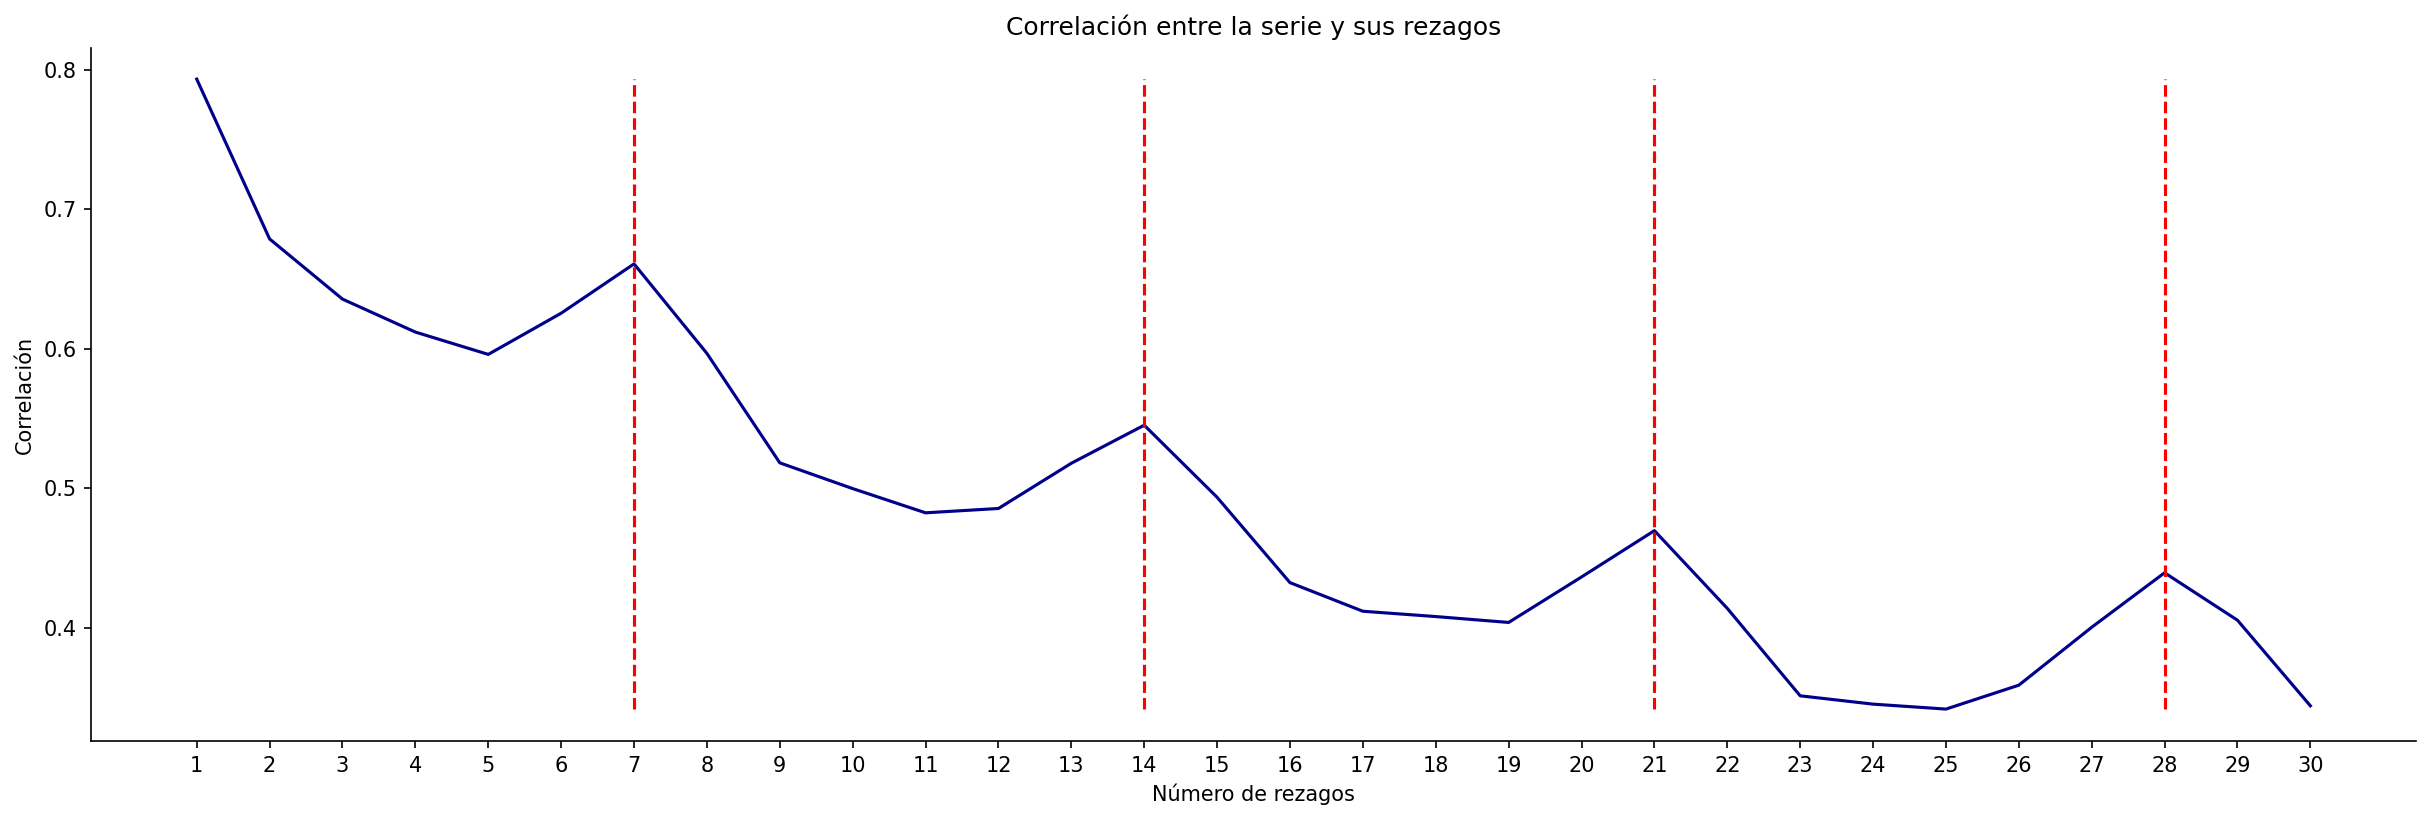

In [55]:
fig, ax = plt.subplots(figsize = (20,6), dpi = 150)
sns.despine()
plt.plot(range(1,31), correlaciones, color = "darkblue")
plt.xticks(range(1,31),range(1,31));
plt.title("Correlación entre la serie y sus rezagos");
plt.xlabel("Número de rezagos");
plt.ylabel("Correlación");
# Pintamos lineas verticales en rojo desde 7 hasta 31 dando saltos de 7 unidades.
plt.vlines(range(7, 31, 7), min(correlaciones), max(correlaciones), colors = 'red', linestyles = "dashed");

Vamos a construir la serie rezagada 7 días para analizar su comportamiento

In [56]:
# Rezagamos la serie 7 días (una semana)
serie_compras["n_l7"] = serie_compras["n"].shift(7)

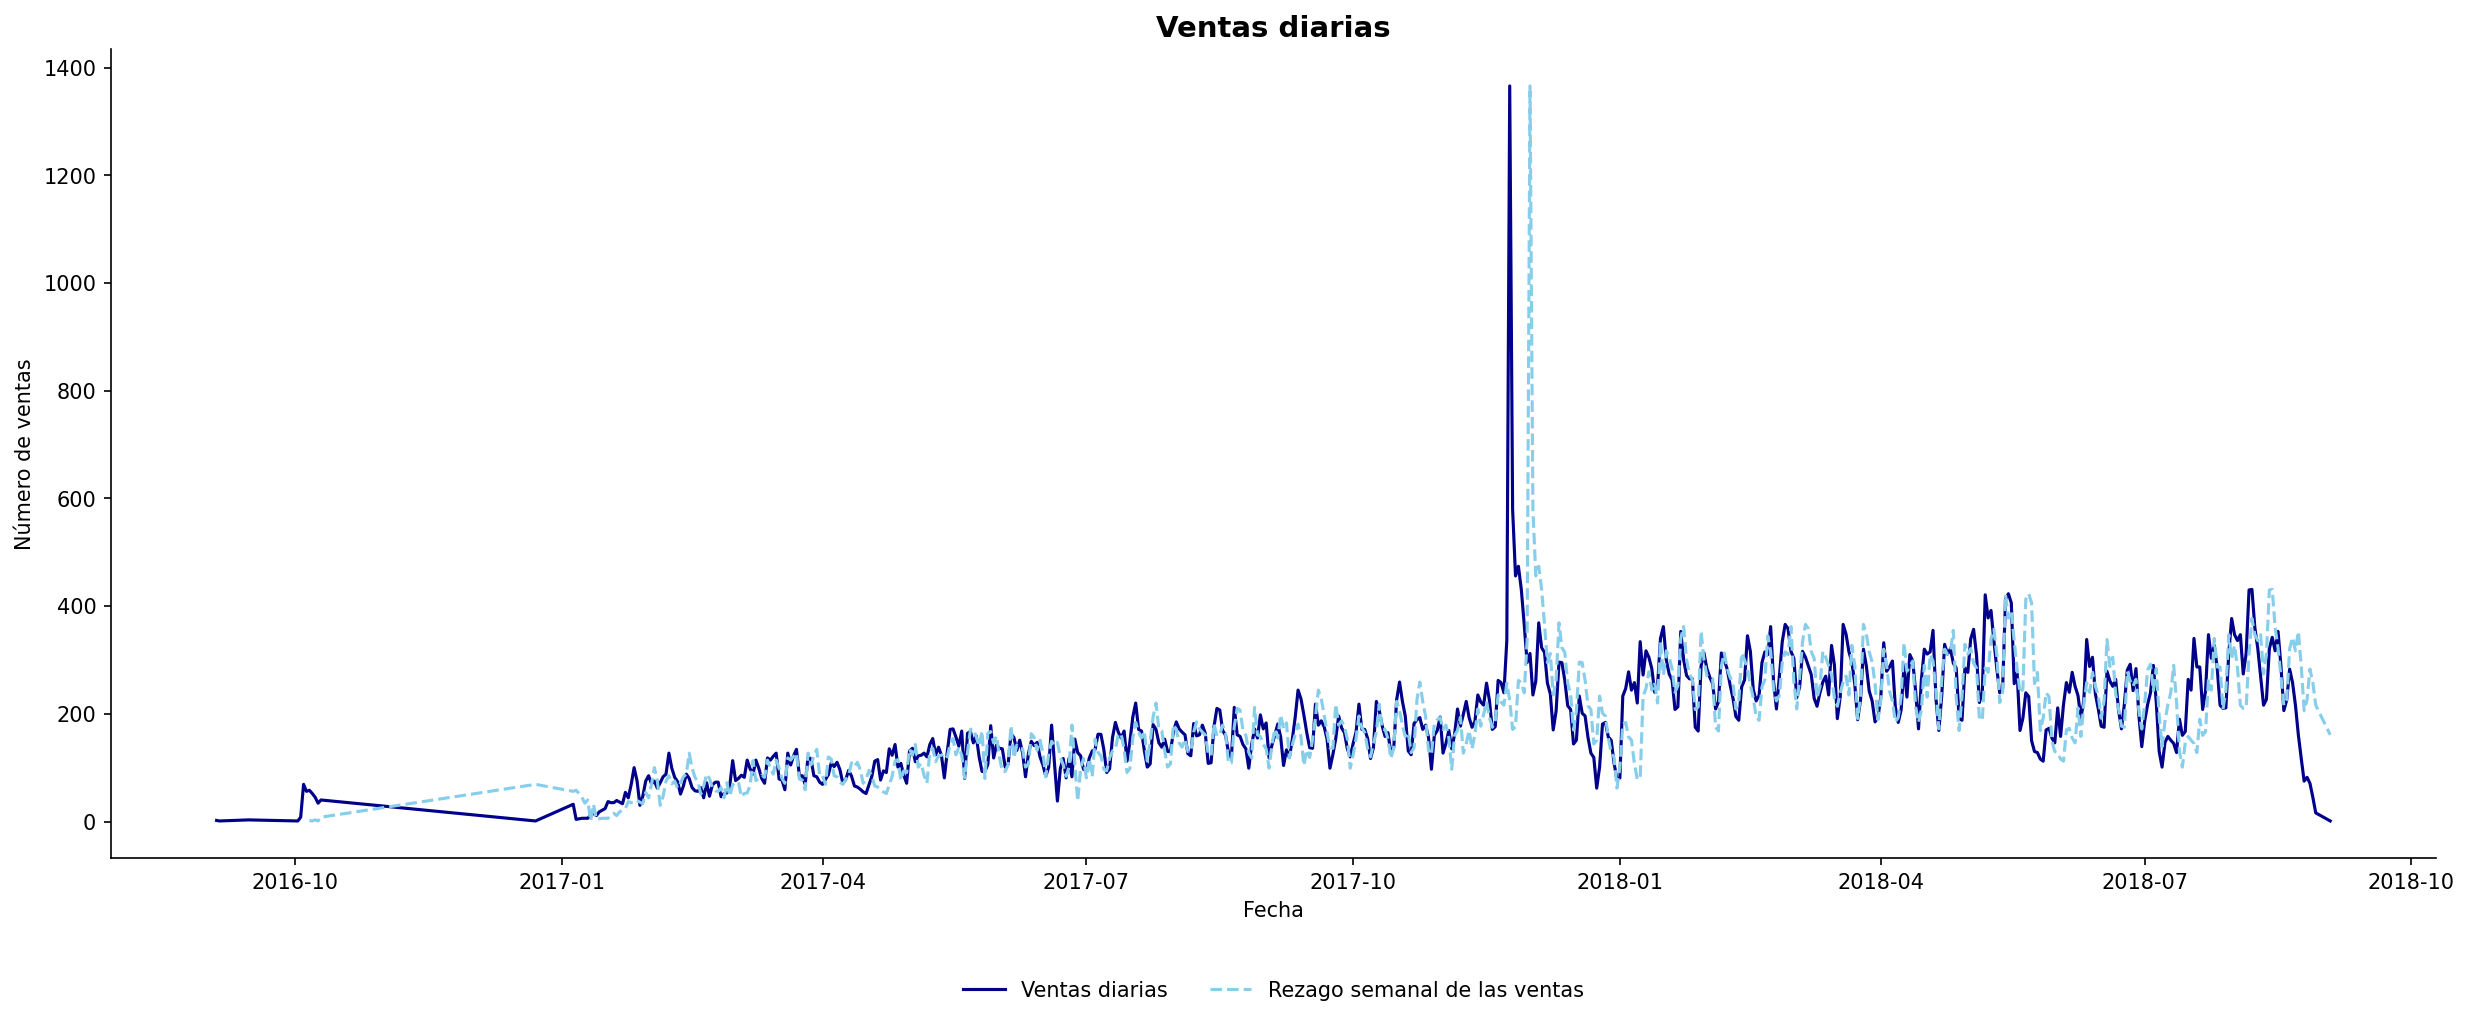

In [57]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(serie_compras["fechas_compra"], serie_compras["n"], color = "darkblue")
plt.plot(serie_compras["fechas_compra"], serie_compras["n_l7"], color = "skyblue", linestyle = "dashed")
plt.legend(['Ventas diarias', 'Rezago semanal de las ventas'], loc = "lower center", 
           bbox_to_anchor = (0.5, -0.2), ncol = 2, frameon = False);
plt.xlabel("Fecha");
plt.ylabel("Número de ventas");
plt.title("Ventas diarias", fontsize = 14, fontweight = "bold");

In [58]:
# Cojamos solo los últimos 3 meses
fecha_maxima = serie_compras["fechas_compra"].max()
fecha_maxima

datetime.date(2018, 9, 3)

In [59]:
from dateutil.relativedelta import *
punto_corte = fecha_maxima - relativedelta(months = 3)
punto_corte

datetime.date(2018, 6, 3)

In [60]:
ultimos_meses = serie_compras.loc[serie_compras["fechas_compra"] >= punto_corte,]
ultimos_meses.head()

,fechas_compra,n,n_l7
527,2018-06-03,217,112.0
528,2018-06-04,258,170.0
529,2018-06-05,240,173.0
530,2018-06-06,277,155.0
531,2018-06-07,251,146.0


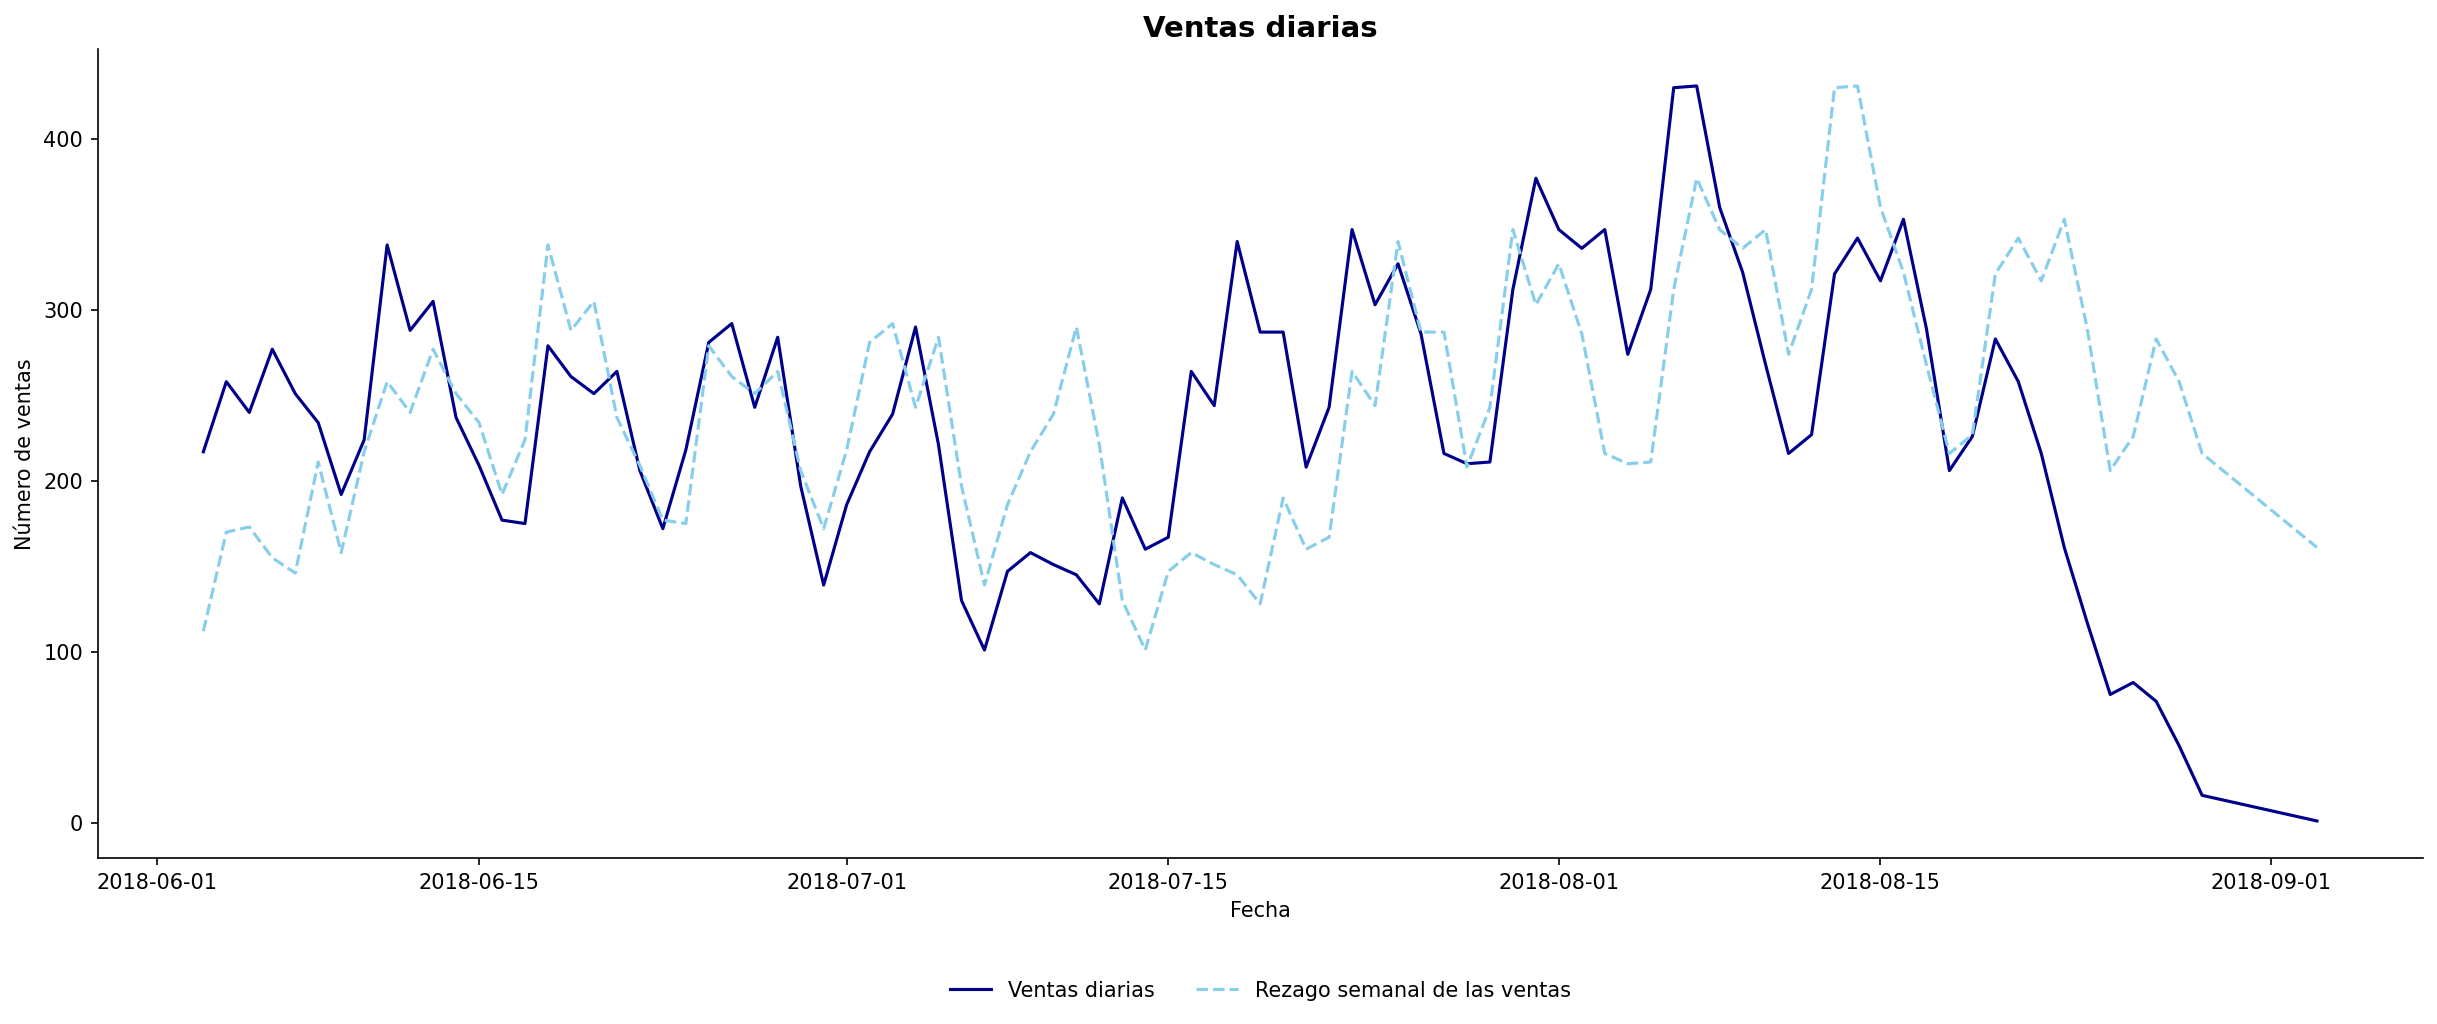

In [61]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["n"], color = "darkblue")
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["n_l7"], color = "skyblue", linestyle = "dashed")
plt.legend(['Ventas diarias', 'Rezago semanal de las ventas'], loc = "lower center", 
           bbox_to_anchor = (0.5, -0.2), ncol = 2, frameon = False);
plt.xlabel("Fecha");
plt.ylabel("Número de ventas");
plt.title("Ventas diarias", fontsize = 14, fontweight = "bold");

Calculemos la diferencia entre el valor real y el rezago

In [62]:
serie_compras["diferencia"] = serie_compras["n"] - serie_compras["n_l7"]

Otra forma de hacerlo

In [63]:
serie_compras["diferencia2"] = serie_compras["n"].diff(7)

In [64]:
serie_compras.tail()

,fechas_compra,n,n_l7,diferencia,diferencia2
611,2018-08-26,82,226.0,-144.0,-144.0
612,2018-08-27,71,283.0,-212.0,-212.0
613,2018-08-28,45,258.0,-213.0,-213.0
614,2018-08-29,16,216.0,-200.0,-200.0
615,2018-09-03,1,161.0,-160.0,-160.0


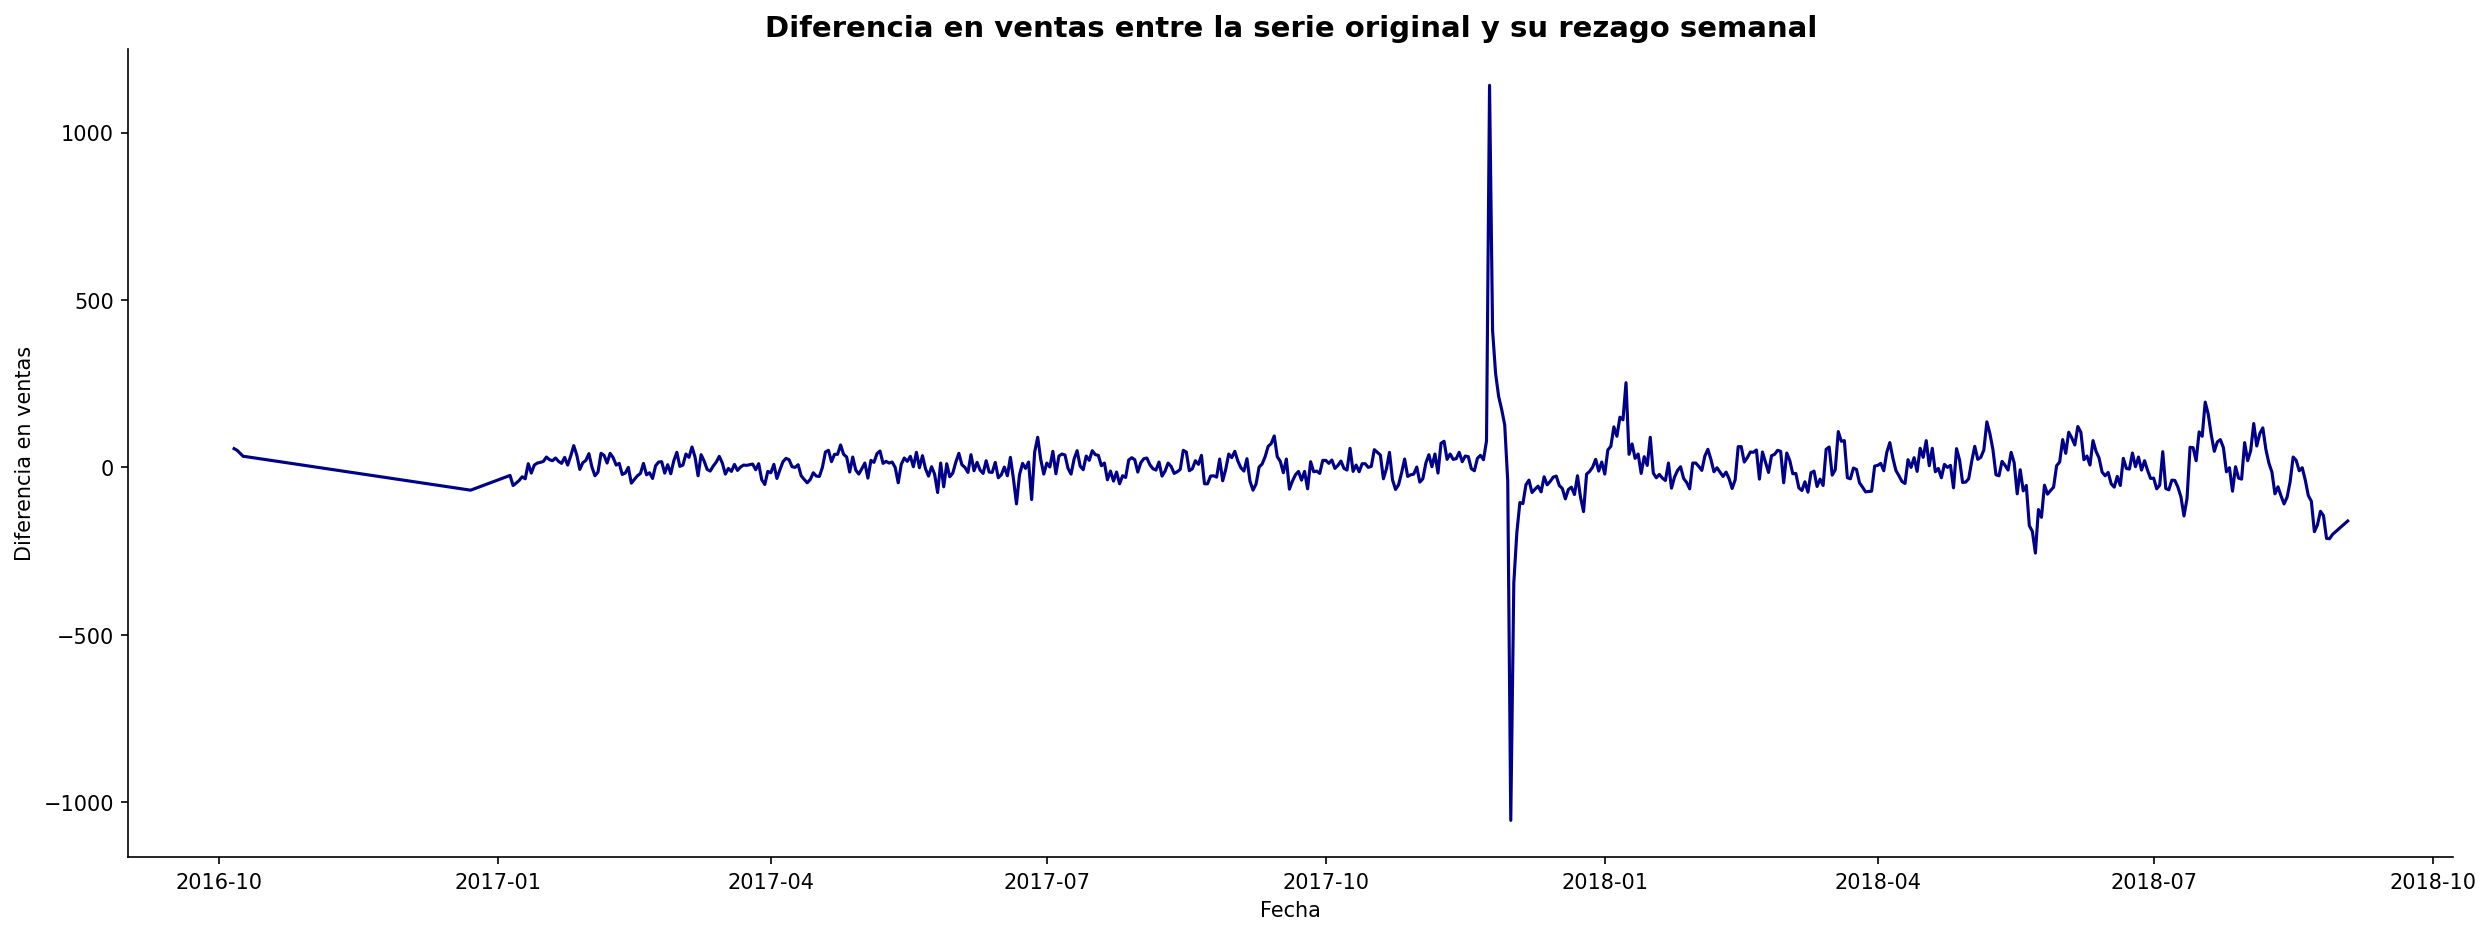

In [65]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(serie_compras["fechas_compra"], serie_compras["diferencia"], color = "darkblue")
plt.xlabel("Fecha");
plt.ylabel("Diferencia en ventas");
plt.title("Diferencia en ventas entre la serie original y su rezago semanal", fontsize = 14, fontweight = "bold");

In [66]:
ultimos_meses = serie_compras.loc[serie_compras["fechas_compra"] >= punto_corte,]

Si nos deshacemos del período atípico en general está entre 200 y -200.

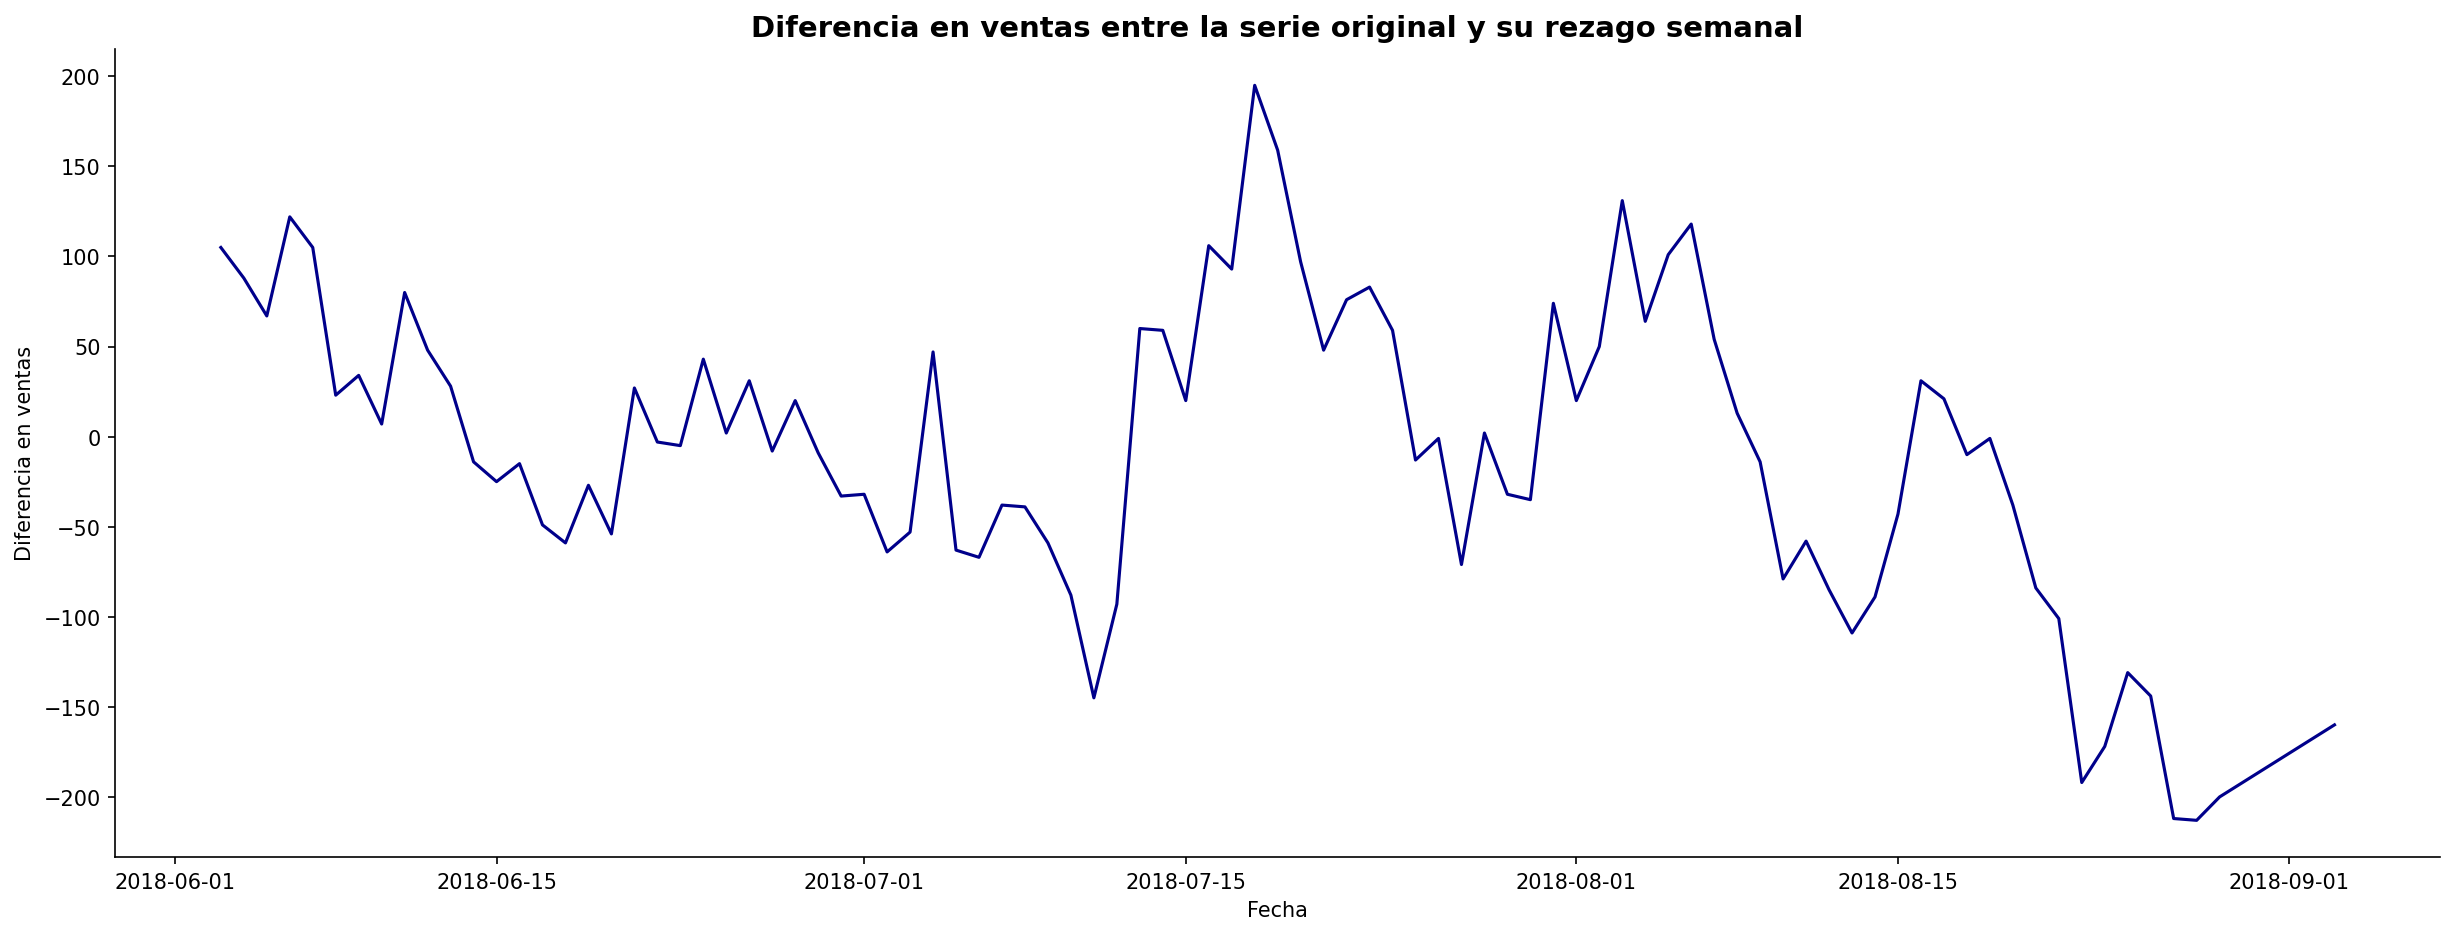

In [67]:
fig, ax = plt.subplots(figsize = (20, 7), dpi = 150)
sns.despine()
plt.plot(ultimos_meses["fechas_compra"], ultimos_meses["diferencia"], color = "darkblue")
plt.xlabel("Fecha");
plt.ylabel("Diferencia en ventas");
plt.title("Diferencia en ventas entre la serie original y su rezago semanal", fontsize = 14, fontweight = "bold");

In [68]:
ultimos_meses["diferencia"].describe()

count     89.000000
mean      -8.067416
std       84.934306
min     -213.000000
25%      -59.000000
50%       -5.000000
75%       50.000000
max      195.000000
Name: diferencia, dtype: float64

In [69]:
serie_compras["n"].describe()

count     616.000000
mean      182.873377
std       105.888023
min         1.000000
25%       112.000000
50%       169.000000
75%       245.250000
max      1366.000000
Name: n, dtype: float64

9. Convierta la variable de monto de pago a categórica y grafique el número de transacciones en cada categoría creada.

In [70]:
pagos['payment_value'].describe()

count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64

In [71]:
# pd.cut() nos permite pasar una variable continua a categórica 
pagos['categoria_pago'] = pd.cut(pagos['payment_value'],                           
                                 # Pasamos los limites de los intervalos en los que se divide la variable. 
                                 # También se puede decir el número de grupos en los que se desea dividir: bins = 5.               
                                 bins = [0, 50, 100, 200, 1000, pagos['payment_value'].max()],    
                                 # Los nombres de las categorías creadas. Por ejemplo, la categoría bajo corresponde a 0 < pagos <= 50
                                 labels = ['Bajo', 'Medio-Bajo', 'Medio', 'Medio-Alto', 'Alto'])  

In [72]:
pagos['categoria_pago']

0         Medio-Bajo
1               Bajo
2         Medio-Bajo
3              Medio
4              Medio
             ...    
103881    Medio-Alto
103882    Medio-Bajo
103883          Bajo
103884    Medio-Alto
103885         Medio
Name: categoria_pago, Length: 103886, dtype: category
Categories (5, object): ['Bajo' < 'Medio-Bajo' < 'Medio' < 'Medio-Alto' < 'Alto']

Text(0, 0.5, 'Cantidad')

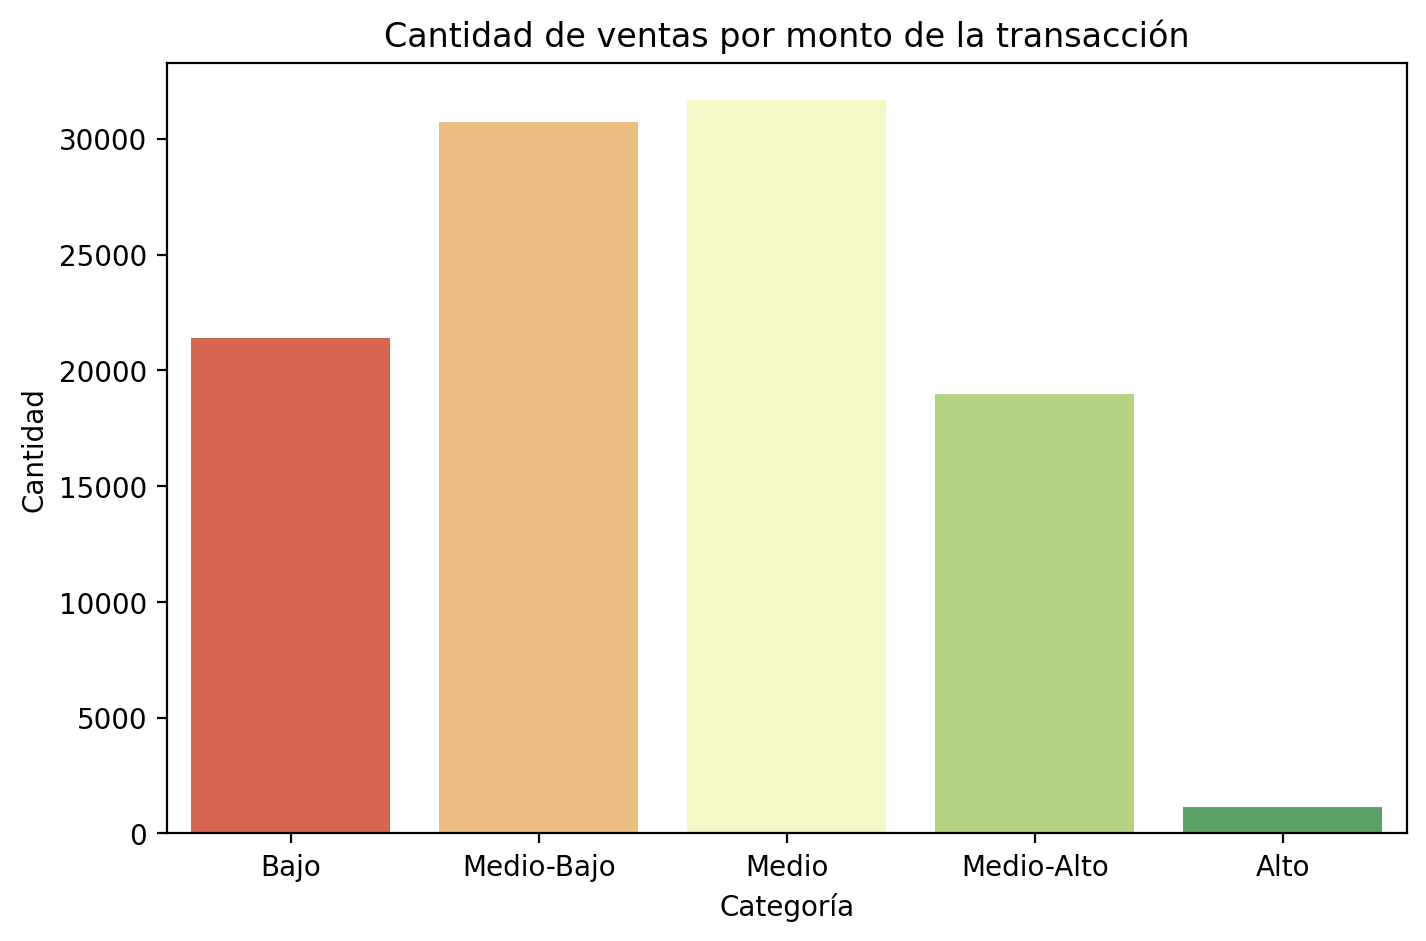

In [73]:
# Gráfico con seaborn que cuenta cuantas veces aparece cada categoría.
fig, ax = plt.subplots(figsize = (8, 5), dpi = 200)
sns.countplot(data = pagos, x = 'categoria_pago', palette = "RdYlGn", ax = ax) 
plt.title("Cantidad de ventas por monto de la transacción")
plt.xlabel("Categoría")
plt.ylabel("Cantidad")

### Regresión Lineal
La regresión lineal es una técnica estadística utilizada para analizar la relación entre una variable una variable dependiente ($Y$) y un conjunto de variables explicativas ($X$). El objetivo de la regresión lineal es encontrar la mejor línea recta que pueda explicar la relación entre las variables y predecir el valor de $Y$ para cualquier valor dado de $X$.

La ecuación de la línea recta se representa como:

$$Y = \alpha + \beta X$$

Donde $\alpha$ es la intersección en $Y$, $\beta$ es la pendiente de la línea recta y $X$ es el valor de la variable independiente. La pendiente de la línea recta indica cuánto aumenta (o disminuye) Y por cada unidad de cambio en $X$.

La regresión lineal se utiliza comúnmente en la investigación y en los negocios para predecir el valor de una variable dependiente en función de una variable independiente. Por ejemplo, se puede utilizar la regresión lineal para predecir la cantidad de ventas que una empresa puede esperar para un determinado nivel de publicidad.

1. Construya el pseudo volumen

In [74]:
ventas3["pseudo_volumen"] = ventas3['product_length_cm'] * ventas3['product_height_cm'] * ventas3['product_width_cm']

2. Construya un gráfico de dispersión entre el pseudo volumen y el precio de flete

<AxesSubplot:xlabel='pseudo_volumen', ylabel='freight_value'>

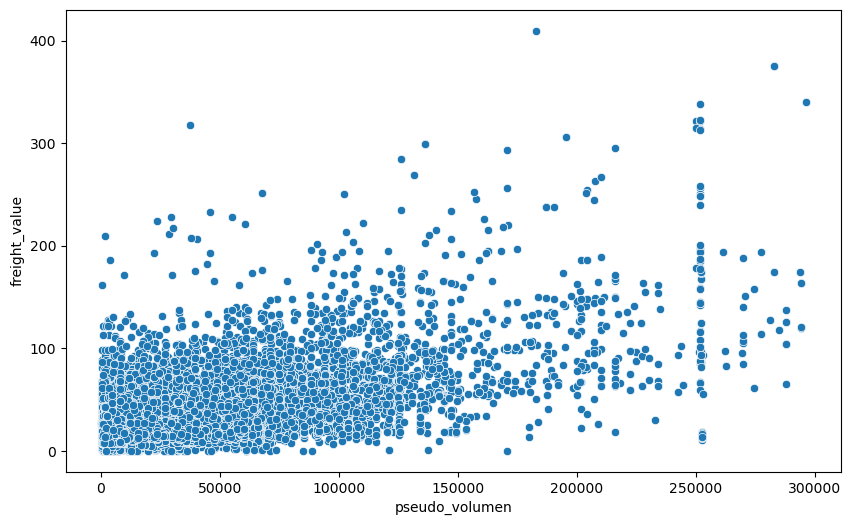

In [75]:
# Son demasiados puntos, no se puede observar con claridad.
fig, ax = plt.subplots(figsize = (10, 6))
sns.scatterplot(data = ventas3, x = "pseudo_volumen", y = "freight_value", ax = ax)

In [76]:
muestra = ventas3.sample(n = 1000, random_state = 666)

<AxesSubplot:xlabel='pseudo_volumen', ylabel='freight_value'>

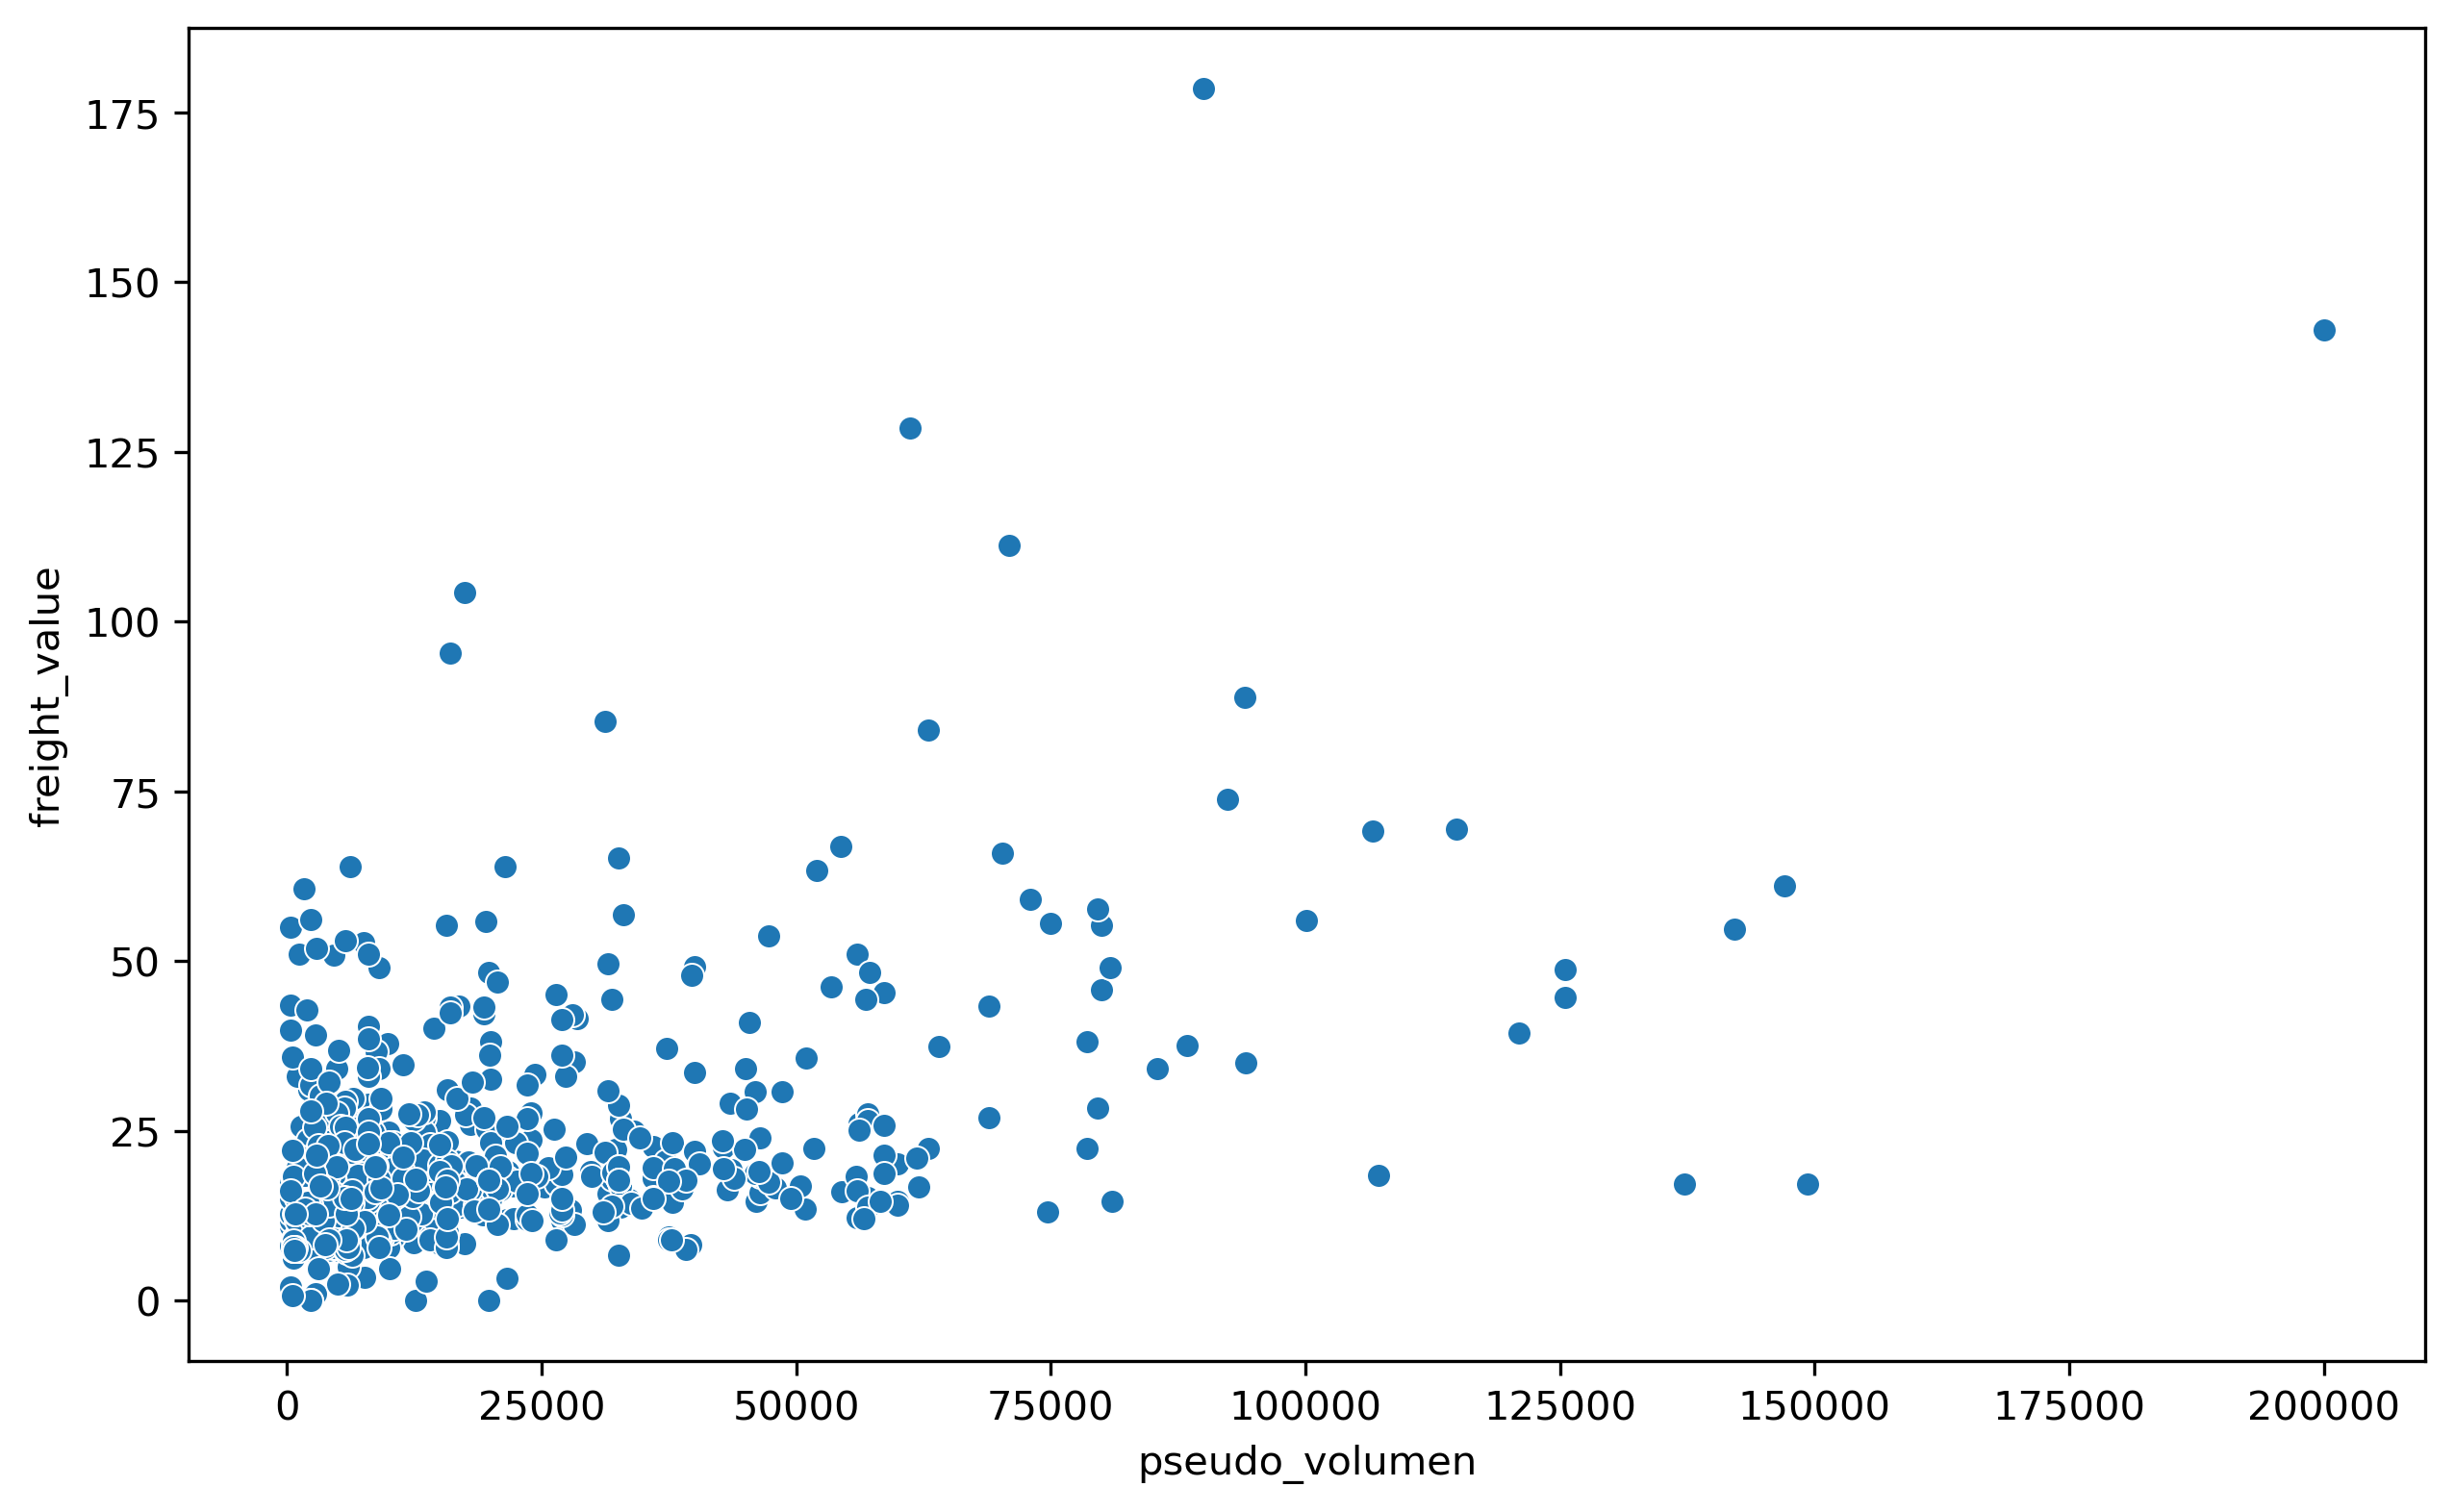

In [77]:
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.scatterplot(data = muestra, x = "pseudo_volumen", y = "freight_value", ax = ax)

Text(0, 0.5, 'Valor del flete')

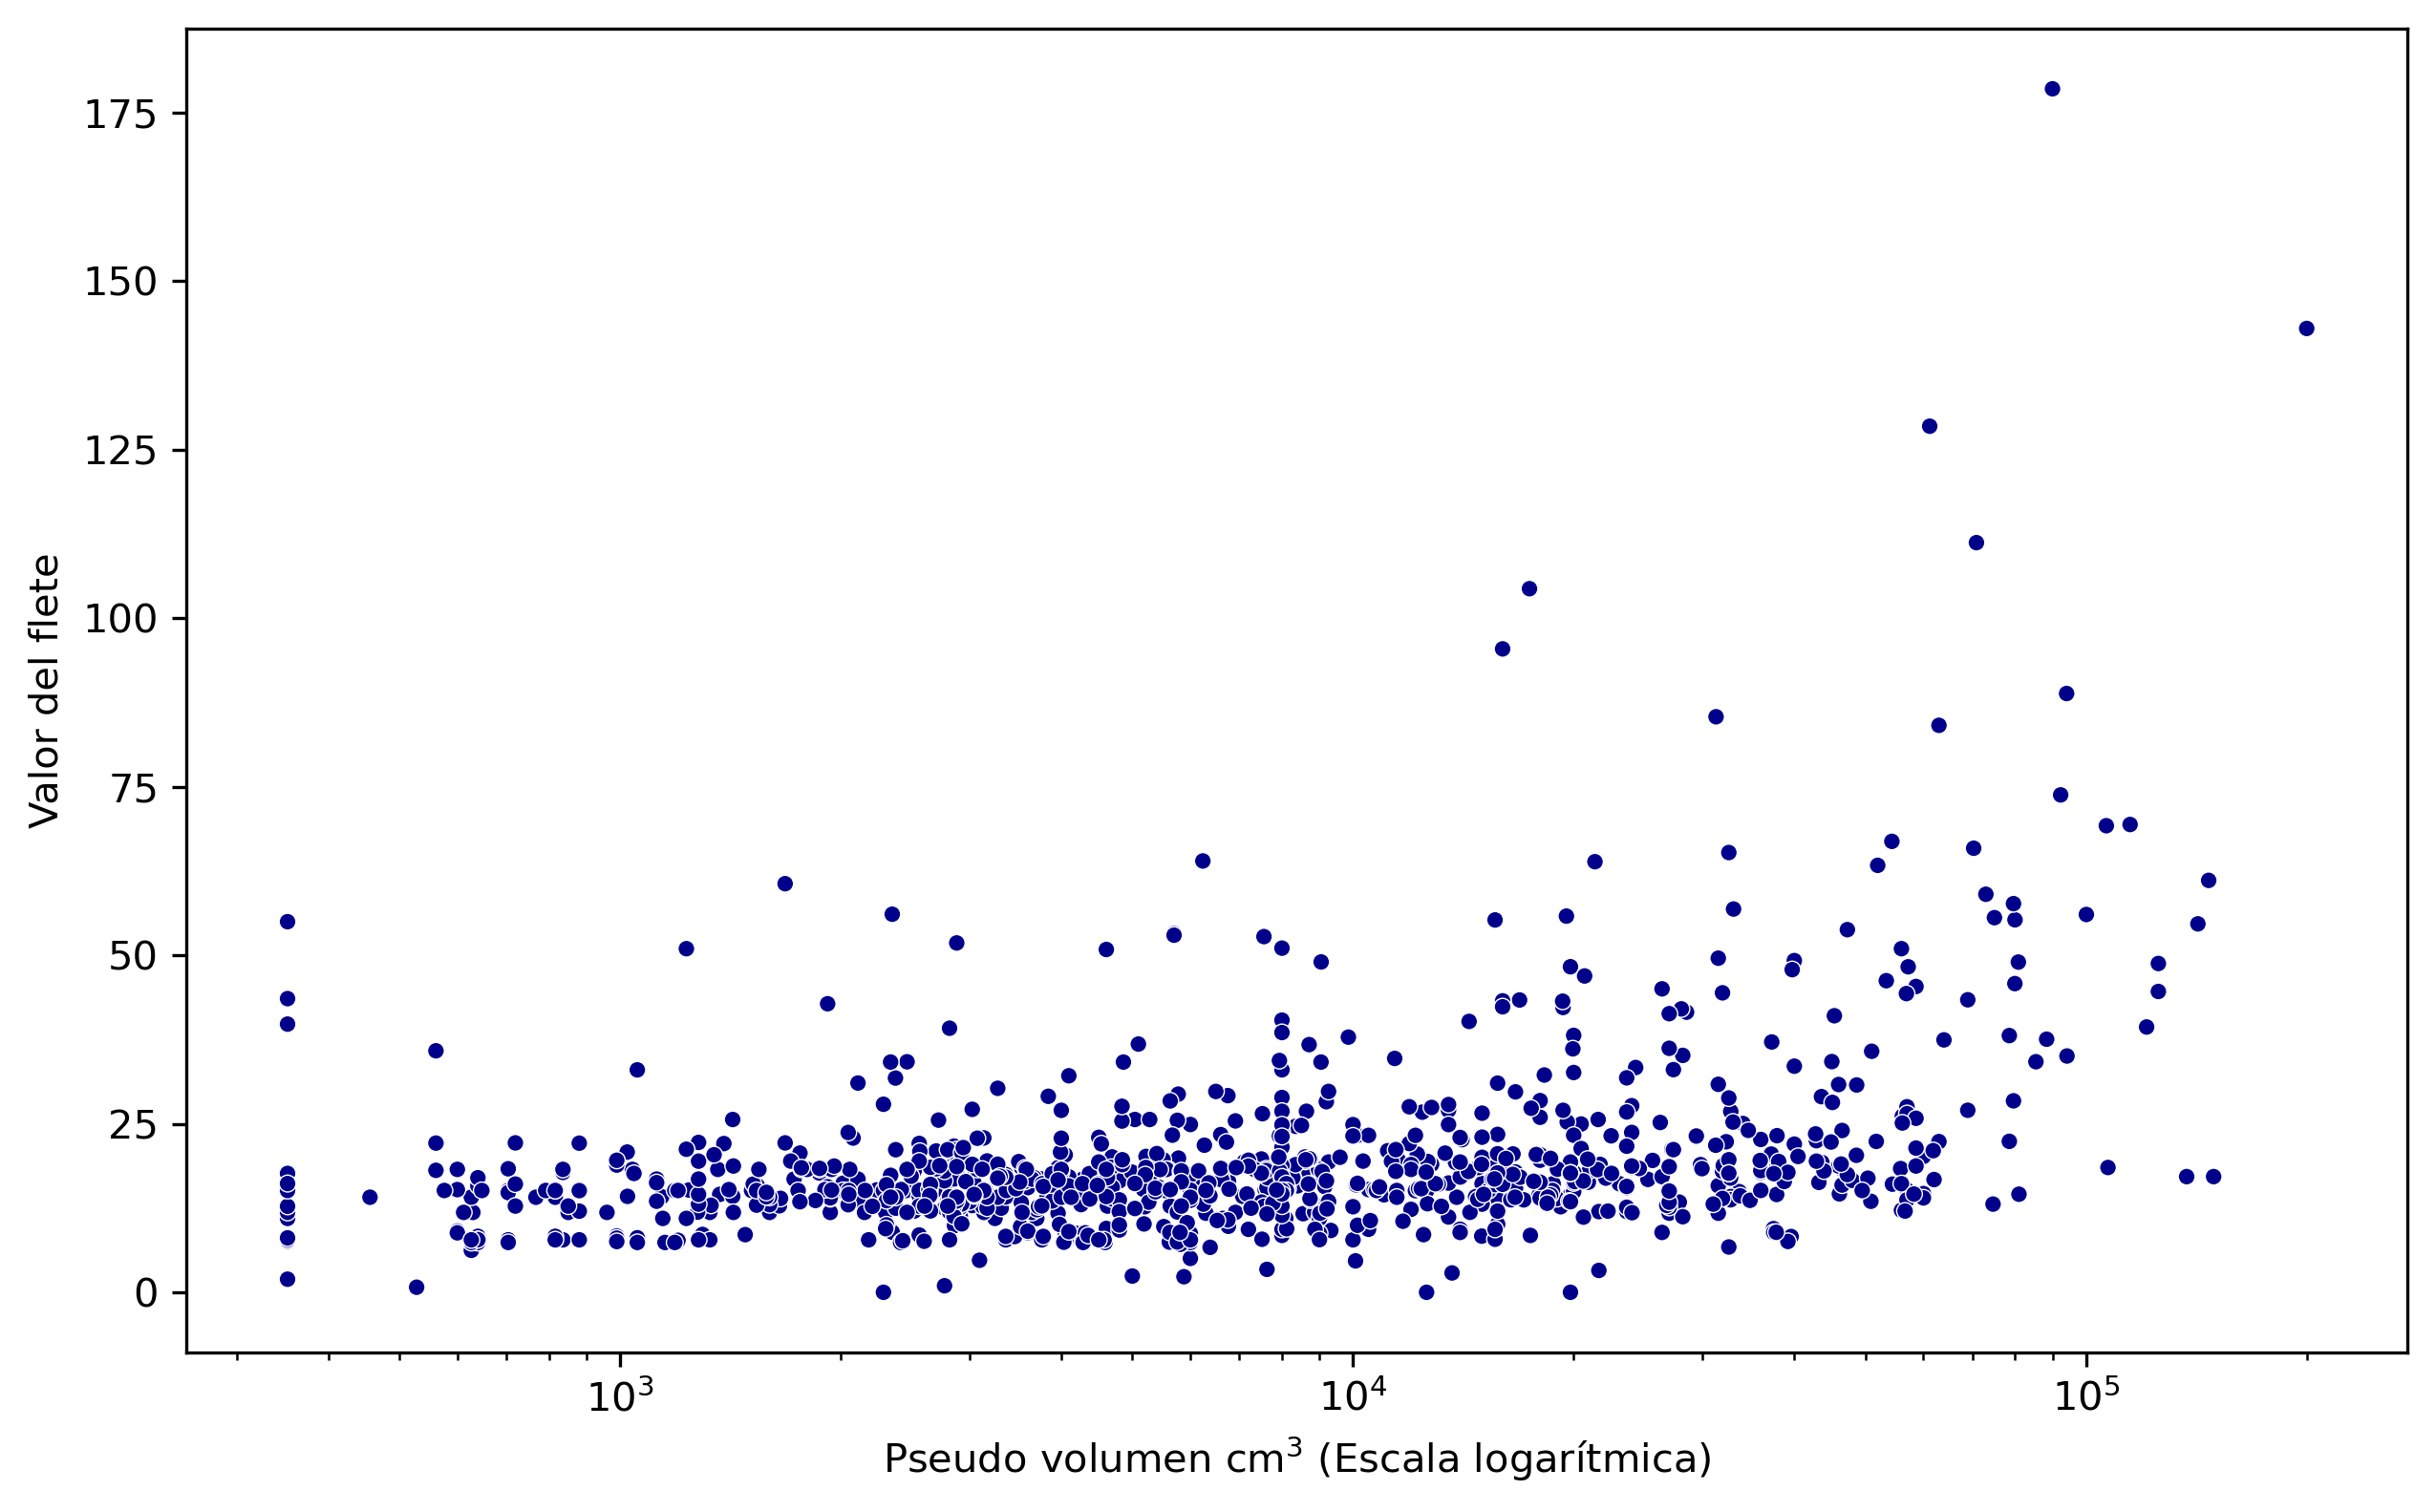

In [78]:
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.scatterplot(data = muestra, x = "pseudo_volumen", y = "freight_value", 
                color = "darkblue", size = 1, legend = False,
                ax = ax)
plt.xscale('log')
plt.xlabel("Pseudo volumen cm$^3$ (Escala logarítmica)")
plt.ylabel("Valor del flete")

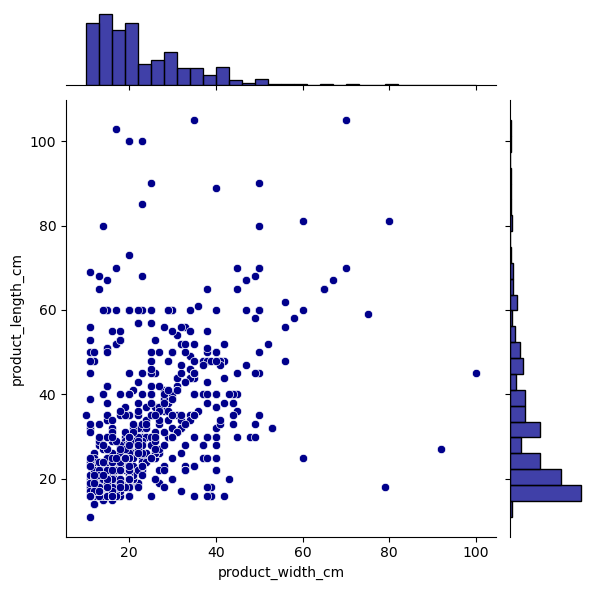

In [79]:
# Veamos la distribución conjunta entre ancho y largo
sns.jointplot(data = muestra, x = "product_width_cm", y = "product_length_cm", 
              color = "darkblue")

3. Construya la regresión entre el precio del flete y el pseudo volumen:
$$ precio\_flete_i = \alpha + \beta*pseudo\_volumen_i +\varepsilon_i $$

In [80]:
import statsmodels.api as sm

In [81]:
# Creamos X
X = muestra[['pseudo_volumen']]
# Añadimos una constante
X = sm.add_constant(X)

X.head()

,const,pseudo_volumen
94155,1.0,2625.0
78623,1.0,4576.0
42818,1.0,3640.0
46096,1.0,43616.0
22839,1.0,6000.0


In [82]:
# Creamos variable y
y = muestra[['freight_value']]
y.head()

,freight_value
94155,13.00
78623,15.10
42818,11.85
46096,19.26
22839,16.11


In [83]:
# Planteamos el modelo
modelo1 = sm.OLS(endog = y, exog = X)
modelo1

In [84]:
# Entrenamos
resultado1 = modelo1.fit()

In [85]:
resultado1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          freight_value   R-squared:                       0.248
Model:                            OLS   Adj. R-squared:                  0.247
Method:                 Least Squares   F-statistic:                     328.9
Date:                Fri, 21 Apr 2023   Prob (F-statistic):           9.26e-64
Time:                        15:10:18   Log-Likelihood:                -3928.8
No. Observations:                1000   AIC:                             7862.
Df Residuals:                     998   BIC:                             7871.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             14.7337      0.476     30.971      0.000      13.800      15.667
pseudo_volumen     0.0003   1.82e-05     18.137      0.000       0.000       0.000
==============================================================================
Omnibus:                      789.609   Durbin-Watson:                   1.937
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            25439.211
Skew:                           3.333   Prob(JB):                         0.00
Kurtosis:                      26.793   Cond. No.                     3.20e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.2e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [86]:
delta = 10000
valor = np.round(resultado1.params["pseudo_volumen"] * delta, 2)
print("Por cada {:,.0f} cm cubicos extras en el artículo comprado, el precio del flete aumenta en ${} reales".format(delta, valor))

Por cada 10,000 cm cubicos extras en el artículo comprado, el precio del flete aumenta en $3.29 reales


In [87]:
# Construyamos el ajuste dentro de muestra
y_hat = resultado1.predict()

Text(0, 0.5, 'Valor del flete')

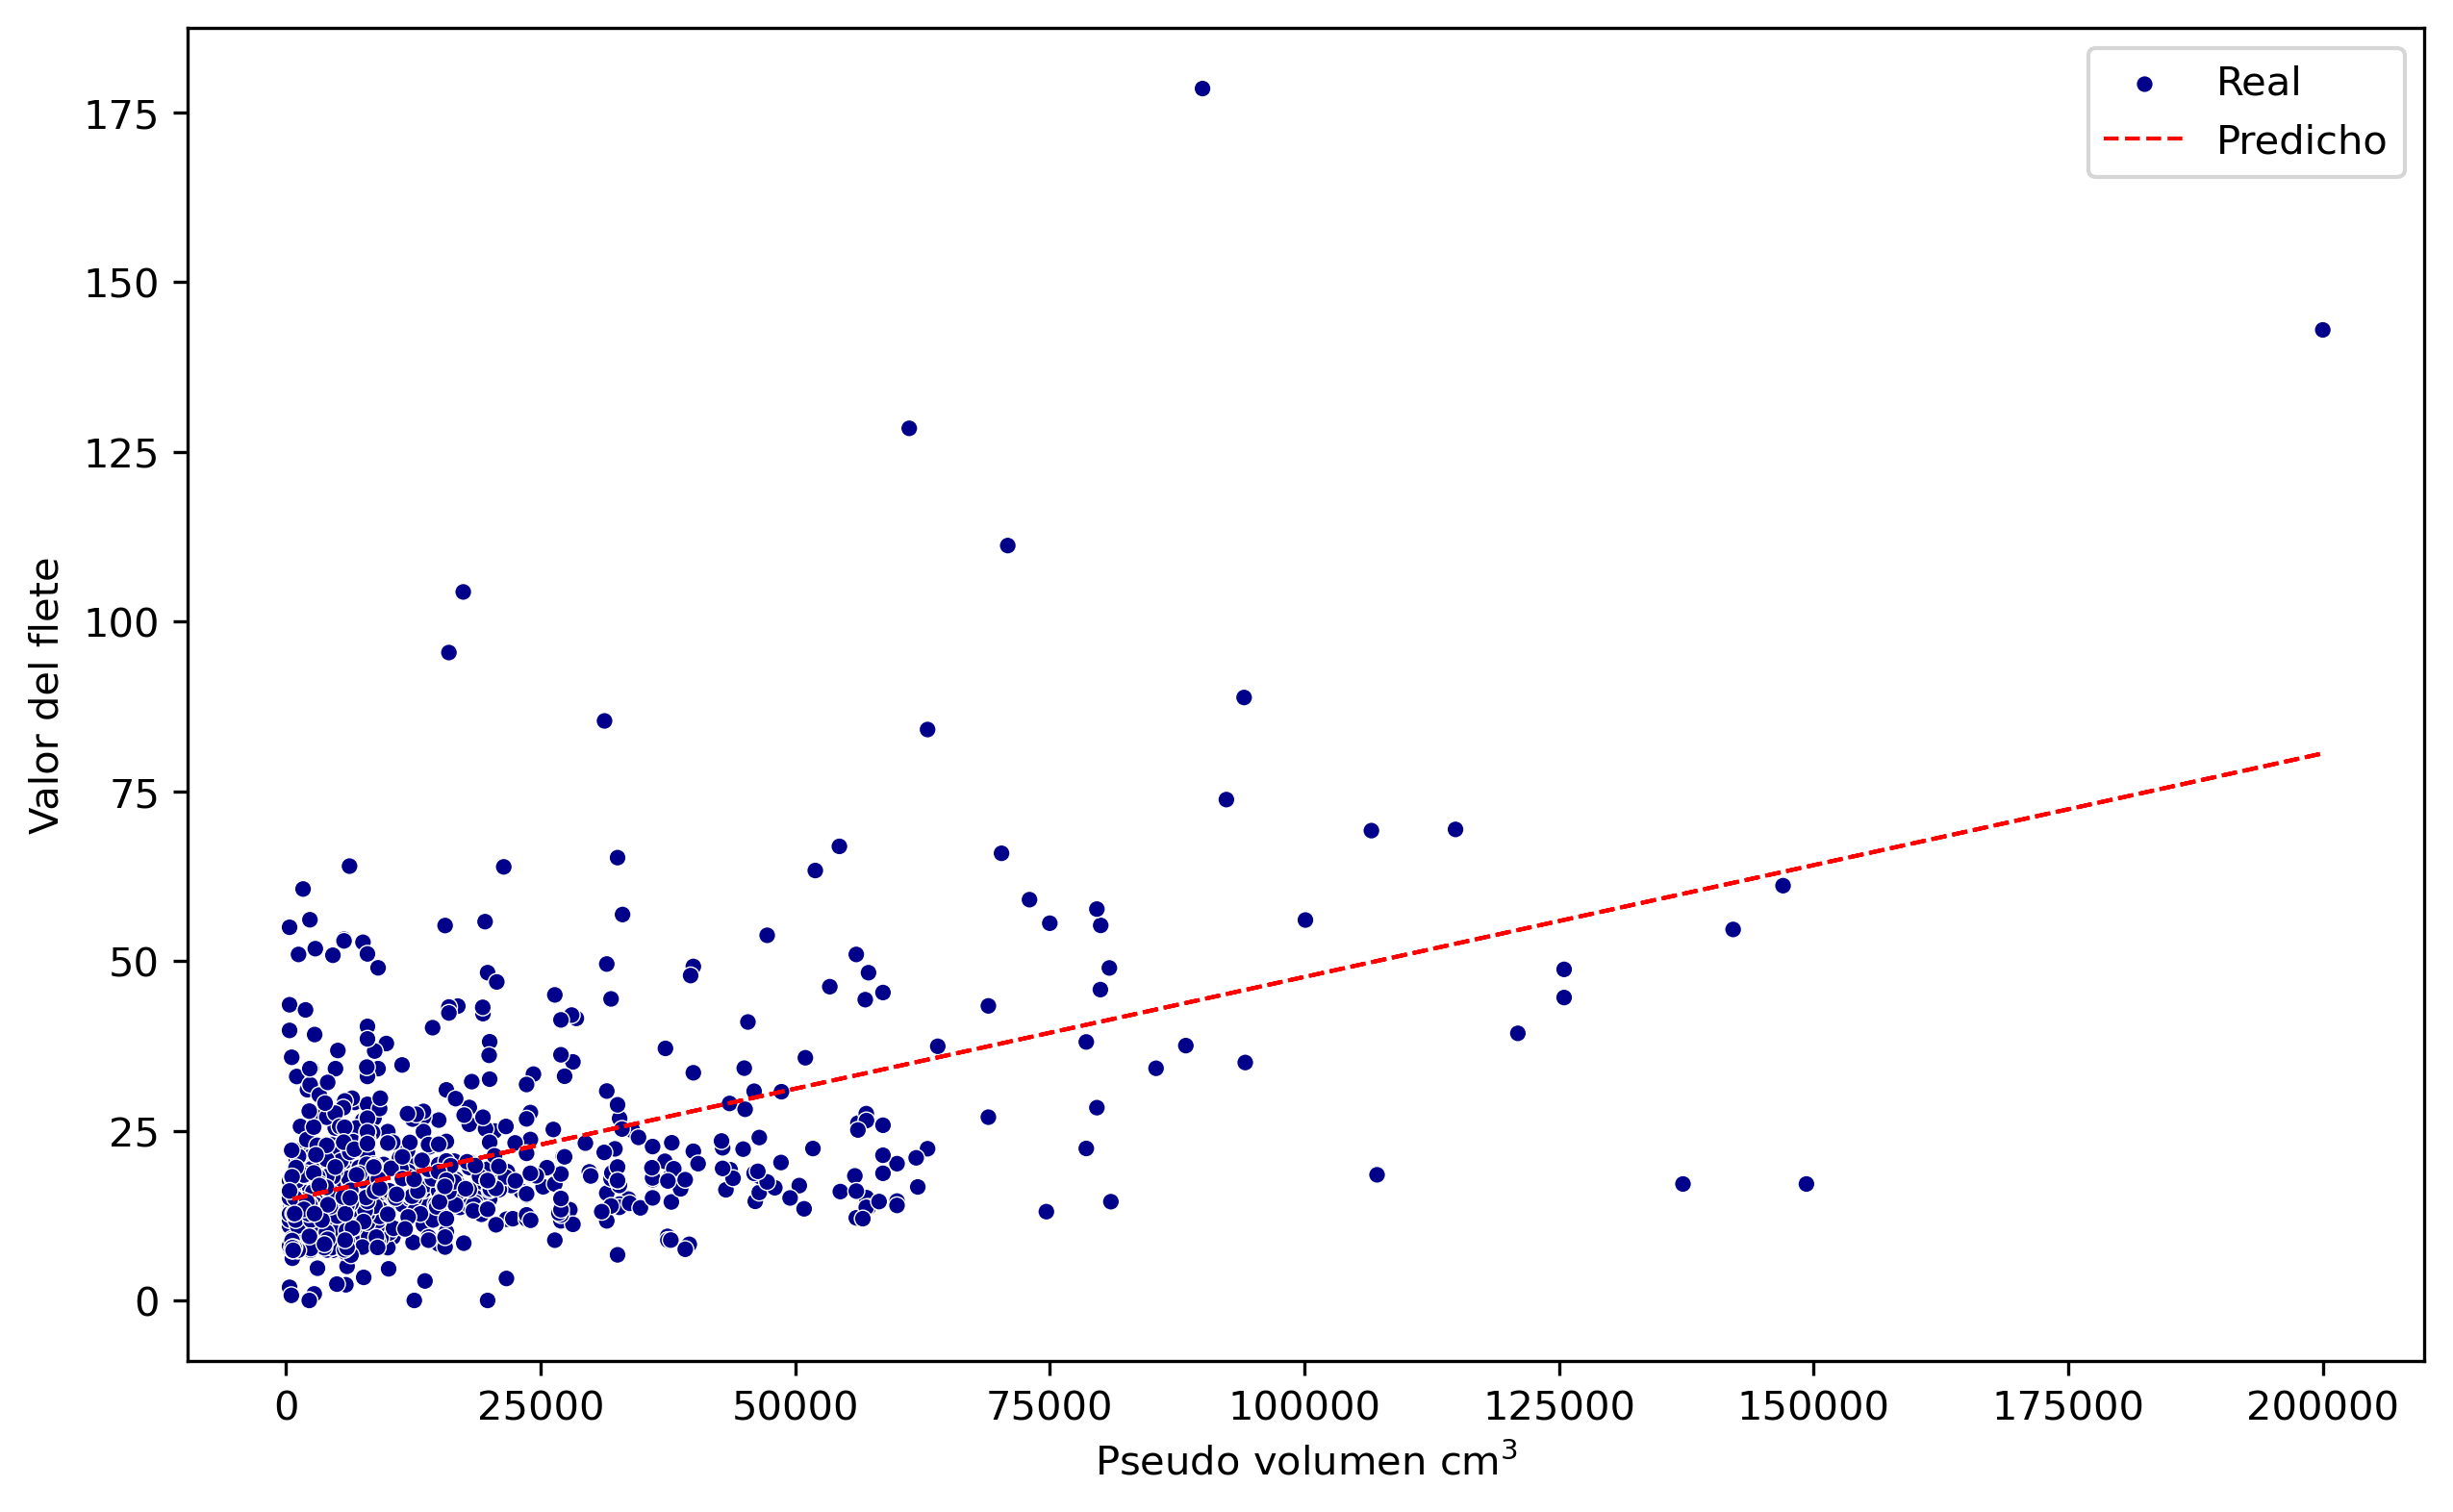

In [88]:
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.scatterplot(data = muestra, x = "pseudo_volumen", y = "freight_value", 
                color = "darkblue", size = 1, legend = False,
                ax = ax)
plt.plot(X["pseudo_volumen"], y_hat, color = 'red', linestyle = "--", linewidth = 1);
plt.legend(["Real", "Predicho"])
plt.xlabel("Pseudo volumen cm$^3$")
plt.ylabel("Valor del flete")

Text(0, 0.5, 'Valor del flete')

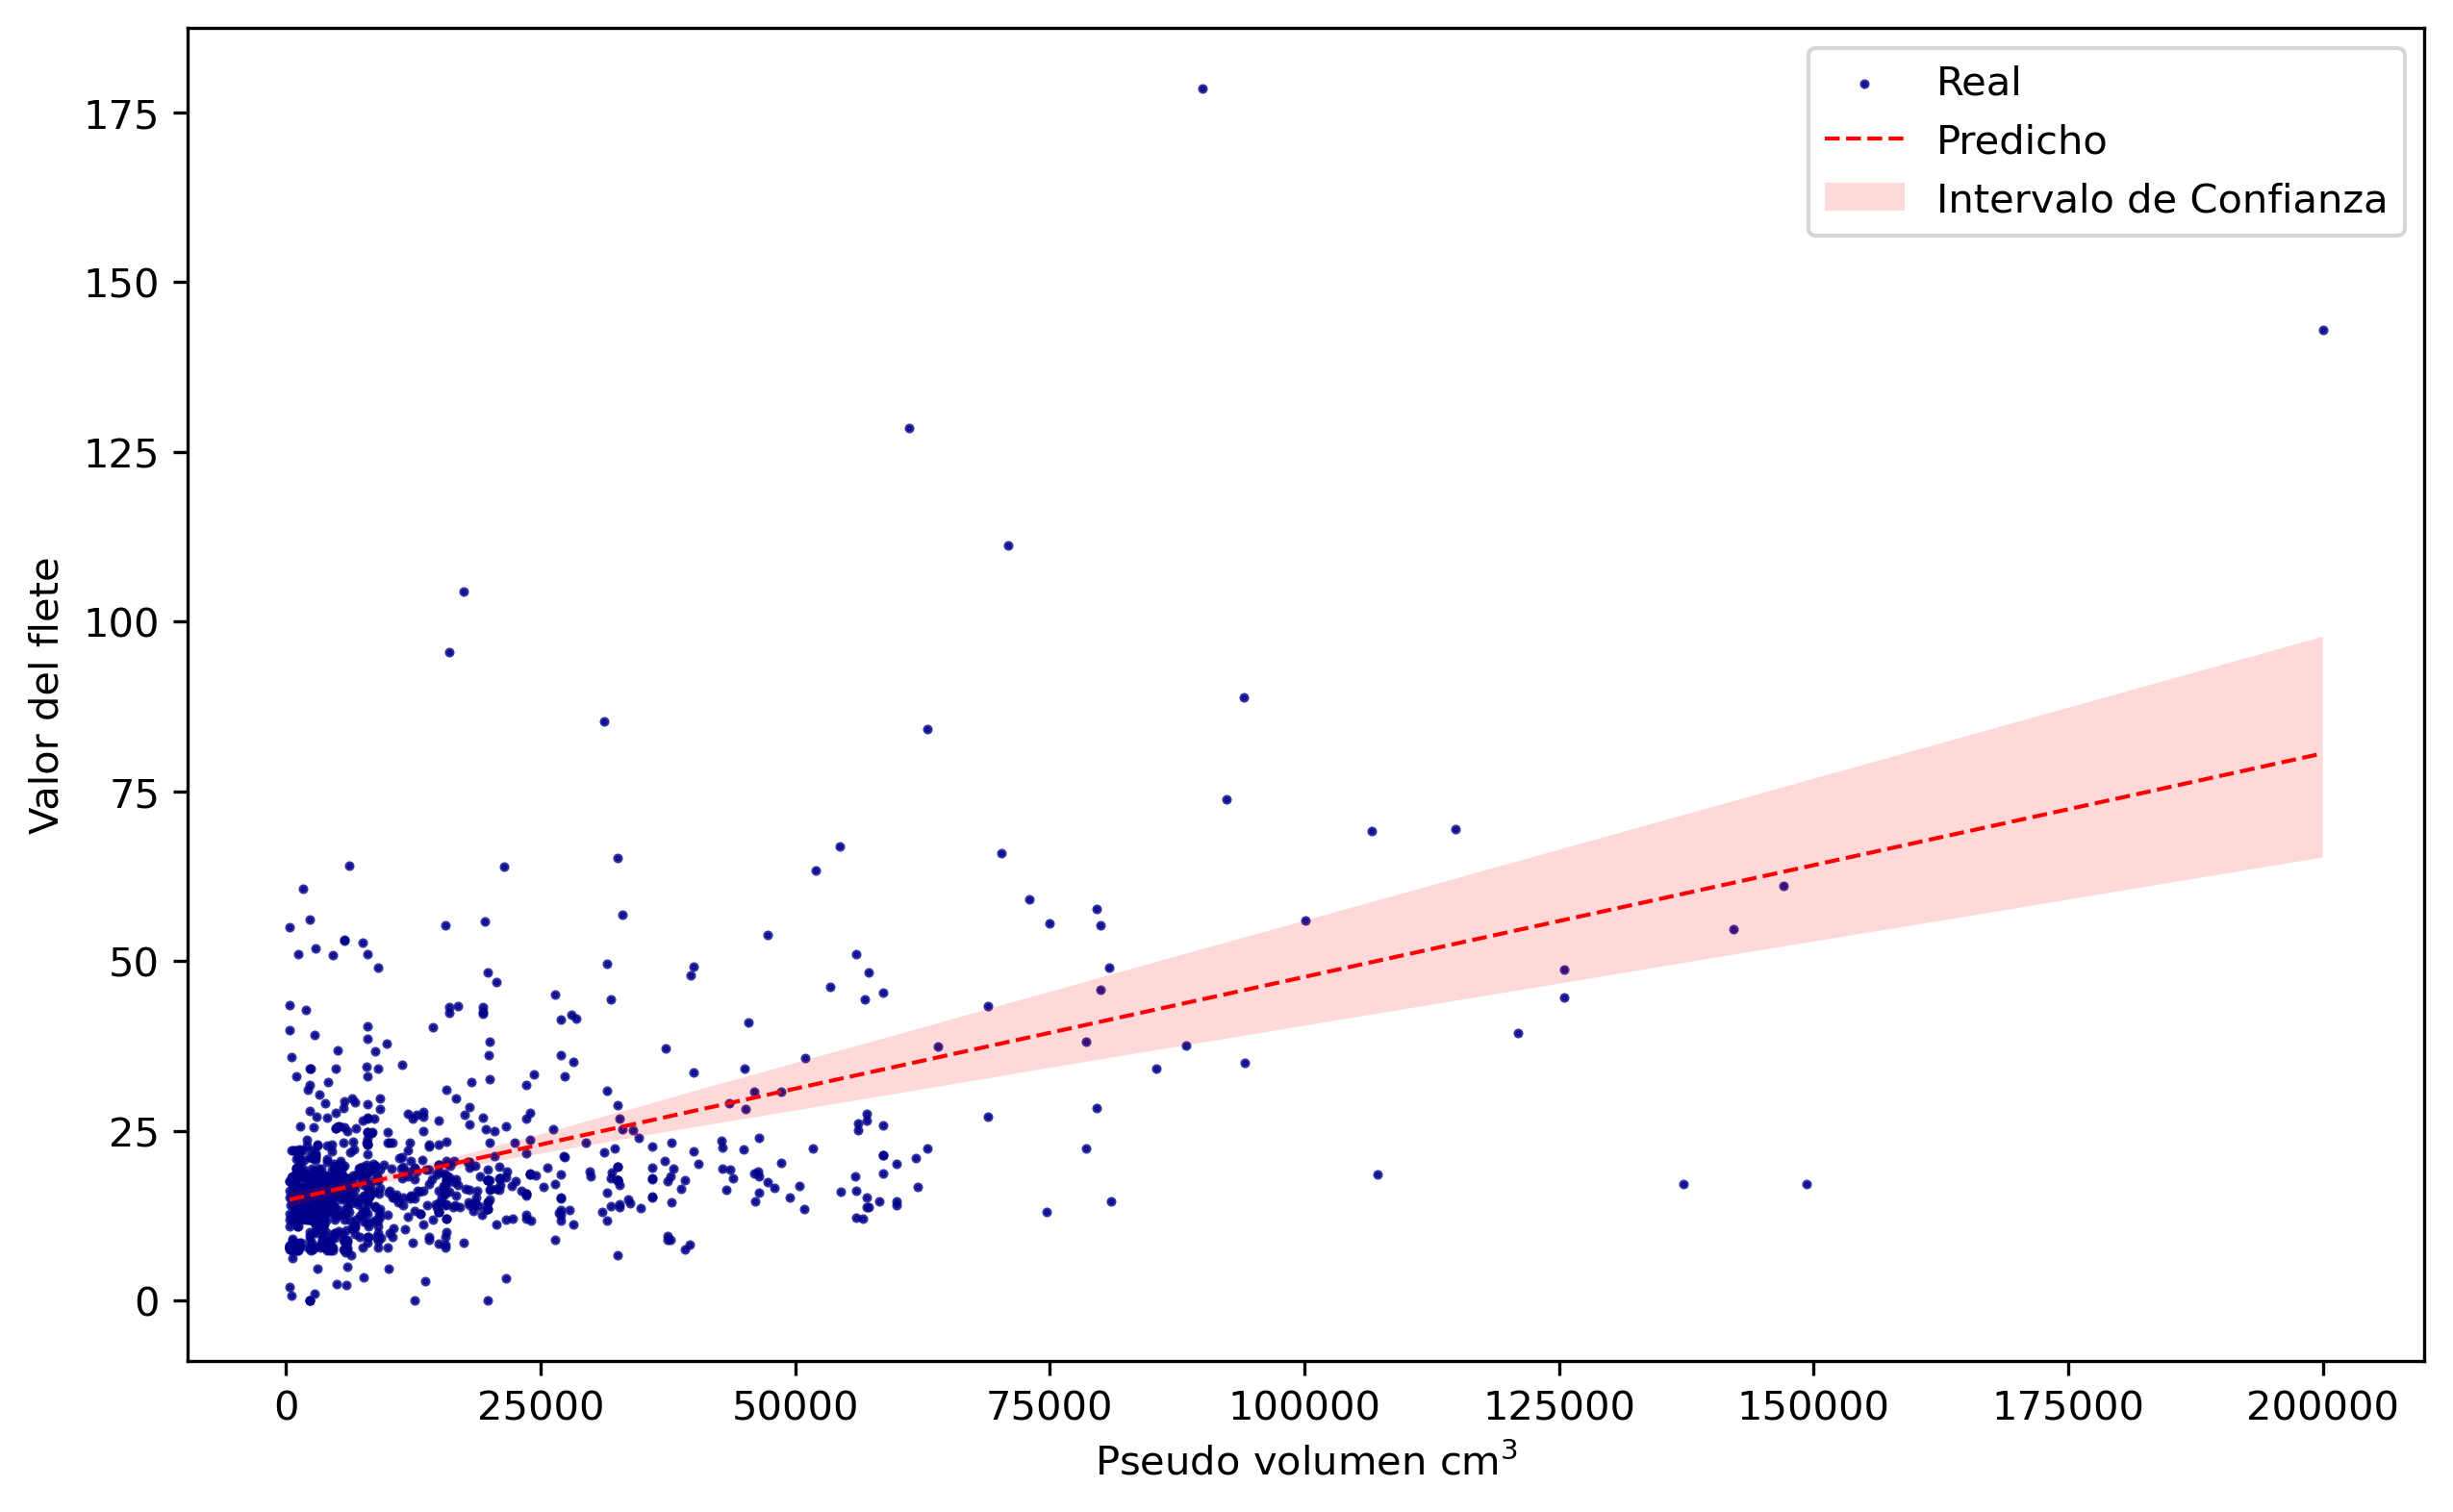

In [89]:
# Gráfico automático
fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)
sns.regplot(x = "pseudo_volumen", y = "freight_value", data = muestra, ax = ax,
            scatter_kws = {"color": "darkblue", "s": 2}, 
            line_kws = {"color": "red", "linestyle": "--", "linewidth": 1})
plt.legend(["Real", "Predicho", "Intervalo de Confianza"])
plt.xlabel("Pseudo volumen cm$^3$")
plt.ylabel("Valor del flete")

## Introducción al webscraping

Web scraping es una técnica usada para automatizar los procesos de extracción de información de sitios web, como tablas, textos o link a otras páginas. **¿Por qué hacer web-scraping?**

-   Funciona mejor que copiar y pegar la información de la web.
-   Es rápido y replicable.

### Robots.txt

El ***robots exclusion standard***, también conocido como ***protocolo de exclusión para robots*** o simplemente `robots.txt`, es un protocolo estándar usado en algunos sitios web para comunicarse con buscadores y otros robots en la web. Este protocolo le indica a los buscadores o robots web sobre las partes de ese sitio web que no ***deben/pueden*** procesarse o escanearse. Veamos algunos ejemplos de `robots.txt`:

**Ejemplo 1: permite a cualquier robot procesar/escanear todos los elementos de la pagína**

<table style="background-color:#f9f2f4">
<tr><th><code style="background-color:#f9f2f4"> # robots.txt for https://example.com/</code></th></tr>
<tr><td><code style="background-color:#f9f2f4"> User-agent: * </code></td></tr>
<tr><td><code style="background-color:#f9f2f4"> Disallow:</code></td></tr>
</table>

**Ejemplo 2: no permite procesar/escanear ningún elemento de la pagína**

<table style="background-color:#f9f2f4">
<tr><th><code style="background-color:#f9f2f4"> # robots.txt for https://example.com/</code></th></tr>
<tr><td><code style="background-color:#f9f2f4"> User-agent: * </code></td></tr>
<tr><td><code style="background-color:#f9f2f4"> Disallow: / </code></td></tr>
</table>

**Ejemplo 3: no permite procesar/escanear ningún elemento del archivo /public/index.html**

<table style="background-color:#f9f2f4">
<tr><th><code style="background-color:#f9f2f4"> # robots.txt for https://example.com/</code></th></tr>
<tr><td><code style="background-color:#f9f2f4"> User-agent: * </code></td></tr>
<tr><td><code style="background-color:#f9f2f4"> Disallow: /public/index.html </code></td></tr>
</table>

**Ejemplo 4: no le permite al robot `BadBot` procesar/escanear ningún elemento de la pagína:**

<table style="background-color:#f9f2f4">
<tr><th><code style="background-color:#f9f2f4"> # robots.txt for https://example.com/</code></th></tr>
<tr><td> <code style="background-color:#f9f2f4"> User-agent: BadBot </code></td></tr>
<tr><td><code style="background-color:#f9f2f4"> Disallow: / </code></td></tr>
</table>

Puede accederse al protocolo de exclusión de una página agregando `robots.txt` al dominio principal de la página. Por ejemplo `https://example.com/robots.txt`

In [101]:
# Abrir el archivo robots.txt de Wikipedia
import webbrowser
webbrowser.open("https://en.wikipedia.org/robots.txt")

True

### Hyper Text Markup Language (HTML)

Un ***Hyper Text Markup Language*** no es un lenguaje de programación, sino más bien un lenguaje de marcado de hipertexto. Un ***HTML*** se escribe en su totalidad con elementos, los que a su vez están constituidos por etiquetas, contenido y atributos (mas adelante veremos que es cada uno de ellos). Los elementos están estructurados como un árbol (tronco, ramas, hojas). Por tanto, para poder extraer un elemento (por ejemplo una hoja), se rastrear la ruta del nodo o etiqueta (indicarle el tronco y la rama que contiene la hoja). Los ***HTML*** son interpretados por los navegadores web visualizando su contenido (una página web por ejemplo) tal y como estamos acostumbrados a verlo. **Puede acceder al HTML de una página web así:**



<center>
<div>
<img src="img/view_html.gif" width="800"/>
</div>
</center>

#### Elementos en un HTML

Un elemento esta compuesto por una etiqueta `<p>`, atributos `id="texto"` (no siempre contiene atributos) y el contenido `Hola mundo`. Por ejemplo:

`<p id="texto"> Hola mundo </p>`

Las etiquetas sirven para delimitar el inicio (`< >`) y el final (`<\ >`) de un elemento. Aquí puede observar algunas etiquetas de elementos comunes en HTML:

-   `<p>`: Párrafos
-   `<head>`: Encabezado de la pagina
-   `<body>`: Cuerpo de la pagina
-   `<h1>, <h2>,...,<hi>`: Encabezados, Secciones
-   `<a>`: links
-   `<li>`: Ítem en una lista
-   `<table>`: Tablas
-   `<td>`: Una celda de datos en una tabla
-   `<div>`: División. Sirve para crear secciones o agrupar contenidos.
-   `<script>`: Se utiliza para insertar o hacer referencia a un script

Por otra parte, los atributos sirven para configurar o proveer información adicional a un elemento. Siempre se expresan en la etiqueta de inicio y tienen asignado un nombre y un valor. Por ejemplo:

`<a class="document-toc-link" col="red">Lista de Atributos</a>`

Aquí la etiqueta del elemento es `a` y tiene dos atributos `class` que indica que el contenido es un link a otro sitio web y `col` que indica que debe visualizarce de color rojo.

####  Mi primer HTML
Ya puedes escribir su primer **HTML**. Abra un archivo en el bloc de notas de su computador y copie y pegue el siguiente código:

```html
<!DOCTYPE html> 
<html>
<meta charset="utf-8">
<head>
<title> Título de la página: ejemplo de clase </title>
</head>
<body>
<h1> Title 1.</h1>
<h2> Subtitle <u>subrayado-1</u>. </h2>
<p> Este es un párrafo muy pequeño que se encuentra dentro de la etiqueta <b>p</b> de <i>html</i> </p>
</body>
</html>
```

Posteriormente guarde el archivo con el nombre que quiera, pero cámbiele la extensión de `.txt` a `.html`. Cuando abra el archivo después de guardarlo debería encontrar algo así

<center>
<div>
<img src="img/my_page.png" width="800"/>
</div>
</center>

**Ejercicio:** Modifique el archivo html que acaba de crear en el bloc de notas agregando un elemento `h1` en el que escriba su nombre y ubiquelo después del elemento `p`. Ejecute el código nuevamente y vea como cambió el html.

Ahora si, vayamos manos a la obra a traer de extraer algunas tablas de la página de Wikipedia de la Copa Mundial de Futbol.

In [103]:
webbrowser.open("https://es.wikipedia.org/wiki/Copa_Mundial_de_F%C3%BAtbol")

True

In [104]:
import requests
from bs4 import BeautifulSoup

In [105]:
html_copa = requests.get("https://es.wikipedia.org/wiki/Copa_Mundial_de_F%C3%BAtbol")

In [107]:
html_copa

<Response [200]>

In [108]:
html_copa.text

'<!DOCTYPE html>\n<html class="client-nojs" lang="es" dir="ltr">\n<head>\n<meta charset="UTF-8"/>\n<title>Copa Mundial de Fútbol - Wikipedia, la enciclopedia libre</title>\n<script>document.documentElement.className="client-js";(function(){var cookie=document.cookie.match(/(?:^|; )eswikimwclientprefs=([^;]+)/);if(cookie){var featureName=cookie[1];document.documentElement.className=document.documentElement.className.replace(featureName+\'-enabled\',featureName+\'-disabled\');}}());RLCONF={"wgBreakFrames":false,"wgSeparatorTransformTable":[",\\t.","\xa0\\t,"],"wgDigitTransformTable":["",""],"wgDefaultDateFormat":"dmy","wgMonthNames":["","enero","febrero","marzo","abril","mayo","junio","julio","agosto","septiembre","octubre","noviembre","diciembre"],"wgRequestId":"cc6bb810-8e19-48be-a9b7-cfdc1918cfb1","wgCSPNonce":false,"wgCanonicalNamespace":"","wgCanonicalSpecialPageName":false,"wgNamespaceNumber":0,"wgPageName":"Copa_Mundial_de_Fútbol","wgTitle":"Copa Mundial de Fútbol","wgCurRevisionI

Ahora vamos a utilizar la librería `Beautiful Soup` para facilitar el análisis del código html. Esto nos va a permitir encontrar con mayor facilidad los diferentes elementos que queremos buscar.

In [110]:
soup = BeautifulSoup(html_copa.text, 'html.parser')

In [111]:
# Se ve igual que antes, pero en el fondo es mucho mejor. Ya veremos por qué
soup

<!DOCTYPE html>

<html class="client-nojs" dir="ltr" lang="es">
<head>
<meta charset="utf-8"/>
<title>Copa Mundial de Fútbol - Wikipedia, la enciclopedia libre</title>
<script>document.documentElement.className="client-js";(function(){var cookie=document.cookie.match(/(?:^|; )eswikimwclientprefs=([^;]+)/);if(cookie){var featureName=cookie[1];document.documentElement.className=document.documentElement.className.replace(featureName+'-enabled',featureName+'-disabled');}}());RLCONF={"wgBreakFrames":false,"wgSeparatorTransformTable":[",\t."," \t,"],"wgDigitTransformTable":["",""],"wgDefaultDateFormat":"dmy","wgMonthNames":["","enero","febrero","marzo","abril","mayo","junio","julio","agosto","septiembre","octubre","noviembre","diciembre"],"wgRequestId":"cc6bb810-8e19-48be-a9b7-cfdc1918cfb1","wgCSPNonce":false,"wgCanonicalNamespace":"","wgCanonicalSpecialPageName":false,"wgNamespaceNumber":0,"wgPageName":"Copa_Mundial_de_Fútbol","wgTitle":"Copa Mundial de Fútbol","wgCurRevisionId":150375488,"

Con el método `find_all()` vamos a poder encontrar los diferentes elementos html que nos interesen. Por ejemplo, encontremos todos los Títulos (`h1`) y los Subtítulos (`h2`).

In [115]:
# Buscar títulos
titulos = soup.find_all("h1")
titulos

[<h1 class="firstHeading mw-first-heading" id="firstHeading"><span class="mw-page-title-main">Copa Mundial de Fútbol</span></h1>]

In [116]:
# Naturalmente solo hay un título
len(titulos)

1

In [118]:
titulos[0].text

'Copa Mundial de Fútbol'

In [119]:
# Buscar subtítulos
subtitulos = soup.find_all("h2")
subtitulos

[<h2 id="mw-toc-heading">Índice</h2>,
 <h2><span class="mw-headline" id="Historia">Historia</span></h2>,
 <h2><span class="mw-headline" id="Desarrollo">Desarrollo</span></h2>,
 <h2><span id="Caracter.C3.ADsticas"></span><span class="mw-headline" id="Características">Características</span></h2>,
 <h2><span id="Resultados_y_estad.C3.ADsticas"></span><span class="mw-headline" id="Resultados_y_estadísticas">Resultados y estadísticas</span></h2>,
 <h2><span class="mw-headline" id="Premios">Premios</span></h2>,
 <h2><span class="mw-headline" id="Impacto_cultural">Impacto cultural</span></h2>,
 <h2><span id="Tecnolog.C3.ADa"></span><span class="mw-headline" id="Tecnología">Tecnología</span></h2>,
 <h2><span id="V.C3.A9ase_tambi.C3.A9n"></span><span class="mw-headline" id="Véase_también">Véase también</span></h2>,
 <h2><span class="mw-headline" id="Notas">Notas</span></h2>,
 <h2><span class="mw-headline" id="Referencias">Referencias</span></h2>,
 <h2><span id="Bibliograf.C3.ADa"></span><span c

In [120]:
len(subtitulos)

14

In [121]:
[i.text for i in subtitulos]

['Índice',
 'Historia',
 'Desarrollo',
 'Características',
 'Resultados y estadísticas',
 'Premios',
 'Impacto cultural',
 'Tecnología',
 'Véase también',
 'Notas',
 'Referencias',
 'Bibliografía',
 'Enlaces externos',
 'Menú de navegación']

Ahora hagamos algo más interesante, busquemos todas las tablas

In [124]:
# Tenemos 14 tablas!
tablas = soup.find_all("table")
len(tablas)

14

Veamos la primera tabla de nuestra lista

In [132]:
tablas[0]

<table class="infobox" style="width:22.7em; line-height: 1.4em; text-align:left; padding:.23em;"><tbody><tr><th class="cabecera fútbol" colspan="3" style="text-align:center;background-color:#BCB;color:black;">Copa Mundial de la FIFA</th></tr><tr><td class="imagen" colspan="3" style="text-align:center;font-size: 92%;;">
<a class="image" href="/wiki/Archivo:ARG_Line-up_-_ARG_vs_MEX_for_2022_FIFA_WC.jpg"><img alt="ARG Line-up - ARG vs MEX for 2022 FIFA WC.jpg" data-file-height="532" data-file-width="800" decoding="async" height="532" src="//upload.wikimedia.org/wikipedia/commons/1/1f/ARG_Line-up_-_ARG_vs_MEX_for_2022_FIFA_WC.jpg" width="800"/></a><br/><div style="display:inline;font-size: 88%;;">La <a href="/wiki/Selecci%C3%B3n_de_f%C3%BAtbol_de_Argentina" title="Selección de fútbol de Argentina">Selección de fútbol de Argentina</a>, vigente campeona del mundo.</div></td></tr><tr><th colspan="3" style="text-align:center;background-color:#BCB;;">Datos generales</th></tr><tr><th scope="row"

Ni idea que será eso. De pronto viendo el texto de la tabla podemos tener una idea del tipo de información que hay en la tabla

In [134]:
tablas[0].text

'Copa Mundial de la FIFA\nLa Selección de fútbol de Argentina, vigente campeona del mundo.Datos generalesSede\nPor elección(Territorios asociados a la FIFA)Organizador\n Federación Internacional de Fútbol Asociación (FIFA)PalmarésCampeón\nARG\xa0Argentina (3)Subcampeón\nFRA\xa0FranciaDatos estadísticosParticipantes\n211 (fase clasificatoria)48 (fase final; desde 2026)Más títulos\nBRA\xa0Brasil (5)Más participaciones\nBRA\xa0Brasil (22)Máximo goleador\n Miroslav Klose (16)Más presencias\n Lionel Messi (26)\n\nSitio oficial [editar datos en Wikidata]'

Si queremos convertir la tabla en un DataFrame debemos convertir nuestro html en texto (`str`) y luego utilizar la función `pd.read_html()` de `pandas`:

In [135]:
pd.read_html(str(tablas[0]))[0]

,Copa Mundial de la FIFA,Copa Mundial de la FIFA.1,Copa Mundial de la FIFA.2
0,"La Selección de fútbol de Argentina, vigente c...","La Selección de fútbol de Argentina, vigente c...","La Selección de fútbol de Argentina, vigente c..."
1,Datos generales,Datos generales,Datos generales
2,Sede,Por elección(Territorios asociados a la FIFA),Por elección(Territorios asociados a la FIFA)
3,Organizador,Federación Internacional de Fútbol Asociación ...,Federación Internacional de Fútbol Asociación ...
4,Palmarés,Palmarés,Palmarés
5,Campeón,Argentina (3),Argentina (3)
6,Subcampeón,Francia,Francia
7,Datos estadísticos,Datos estadísticos,Datos estadísticos
8,Participantes,211 (fase clasificatoria)48 (fase final; desde...,211 (fase clasificatoria)48 (fase final; desde...
9,Más títulos,Brasil (5),Brasil (5)


La tabla que se extrajo fue la siguiente:
<center>
<div>
<img src="img/world_cup1.png"/>
</div>
</center>

Note que por la naturaleza de la tabla, Python no la importó a la perfección. Es necesario hacer una pequeña limpieza de datos. 

Para encontrar una tabla específica dentro de la página, puede ser algo engorrioso tratar de revisar una por una. Otra alternativa más eficiente que tenemos es usar el `Xpath`

#### Xpath

**¿Cómo se puede extraer un elemento especifico de un HTML?**. El lenguaje Xpath (*XML Path Language*) es el sistema que permite construir expresiones usadas para recorrer y consultar los elementos de un documento XML. Es decir, un `XPath` permite buscar un elemento teniendo en cuenta la estructura jerárquica del XML.

<center>
<div>
<img src="img/body_html.png"/>
</div>
</center>

Por el ejemplo, para obtener el elemento marcado con un recuadro rojo, el `xpath` le indica a Python cuál es el camino que debe recorrer para extraer ese elemento. Puede obtener el `xpath` inspeccionando el elemento así: 

<center>
<div>
<img src="img/xpath.gif"/>
</div>
</center>

Por ejemplo, busquemos el `Xpath` para sacar la tabla de goleadores.

In [148]:
goleadores_xpath = '//*[@id="mw-content-text"]/div[1]/table[7]'

In [166]:
pd.read_html(str(tablas[7]))[0]

,Pos.,Jugador[121]​,Selección,Goles,Partidos,Promedio,Torneos jugados
0,1.0,Miroslav Klose,Alemania,16,24,67,"2002, 2006, 2010 y 2014"
1,2.0,Ronaldo,Brasil,15,19,79,"1994, 1998, 2002 y 2006"
2,3.0,Gerd Müller,Alemania,14,13,108,1970 y 1974
3,4.0,Just Fontaine,Francia,13,6,217,1958
4,NaN,Lionel Messi,Argentina,13,26,5,"2006, 2010, 2014, 2018 y 2022"
5,6.0,Kylian Mbappé,Francia,12,14,86,2018 y 2022
6,NaN,Pelé,Brasil,12,14,86,"1958, 1962, 1966 y 1970"
7,8.0,Sándor Kocsis,Hungría,11,5,22,1954
8,NaN,Jürgen Klinsmann,Alemania,11,17,65,"1990, 1994 y 1998"
9,10.0,Helmut Rahn,Alemania,10,10,1,1954 y 1958


Otra forma sencilla es hacer uso de `pandas` directamente

In [167]:
world_cup = pd.read_html("https://es.wikipedia.org/wiki/Copa_Mundial_de_F%C3%BAtbol")

In [169]:
len(world_cup)

13

In [170]:
world_cup[7]

,Pos.,Jugador[122]​,Selección,P. J.,Minutos,Torneos jugados
0,1.0,Lionel Messi,Argentina,26,2315,"2006, 2010, 2014, 2018 y 2022"
1,2.0,Lothar Matthäus,Alemania,25,2052,"1982, 1986, 1990, 1994 y 1998"
2,3.0,Miroslav Klose,Alemania,24,1790,"2002, 2006, 2010 y 2014"
3,4.0,Paolo Maldini,Italia,23,2217,"1990, 1994, 1998 y 2002"
4,5.0,Cristiano Ronaldo,Portugal,22,1764,"2006, 2010, 2014, 2018 y 2022"
5,6.0,Uwe Seeler,Alemania,21,1980,"1958, 1962, 1966 y 1970"
6,NaN,Diego Maradona,Argentina,21,1938,"1982, 1986, 1990 y 1994"
7,NaN,Wladyslaw Zmuda,Polonia,21,1808,"1974, 1978, 1982 y 1986"
8,9.0,Javier Mascherano,Argentina,20,1950,"2006, 2010, 2014 y 2018"
9,NaN,Philipp Lahm,Alemania,20,1920,"2006, 2010 y 2014"


In [172]:
world_cup[1]

,Año,Sede,Costo (en miles de millones USD),Fuente
0,1994,Estados Unidos,0.5,[110]​
1,1998,Francia,2.3,[110]​
2,2002,Corea Japón,7.0,[110]​
3,2006,Alemania,4.3,[110]​
4,2010,Sudáfrica,3.6,[110]​
5,2014,Brasil,15.0,[110]​
6,2018,Rusia,11.6,[110]​
7,2022,Catar,220.0,[110]​
